<a href="https://colab.research.google.com/github/mohammadanas7777/Exploratory-Data-Analysis-projects/blob/main/Capstone_Project_Module_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member -** Mohammad Anas

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import math
from numpy import loadtxt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams
!pip install pymysql
import pymysql
from sqlalchemy import create_engine
from sqlalchemy.pool import NullPool

import numpy as np
import seaborn as sns
from scipy.stats import *
import math


from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from xgboost import XGBClassifier
from xgboost import XGBRFClassifier
from sklearn.tree import export_graphviz

# !pip uninstall -y shap
# !pip install shap>=0.48.0
# import shap
import graphviz
sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.4 MB/s eta 0:00:00


### Dataset Loading

In [ ]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
filepath_1 = '/content/drive/MyDrive/Colab Notebooks/Capstone Projects/Zomato Restaurant reviews.csv'
Restaurant_Reviews_df = pd.read_csv(filepath_1)
reviews_df = Restaurant_Reviews_df.copy()

filepath_2 = '/content/drive/MyDrive/Colab Notebooks/Capstone Projects/Zomato Restaurant names and Metadata.csv'
Restaurants_df = pd.read_csv(filepath_2)
restaurants_df = Restaurants_df.copy()

Mounted at /content/drive


### Dataset First View

In [ ]:
# Dataset First Look
reviews_df

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0
...,...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,"2 Reviews , 53 Followers",6/4/2016 22:01,0
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,"65 Reviews , 423 Followers",6/3/2016 10:37,3
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0


In [ ]:
restaurants_df

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."
...,...,...,...,...,...,...
100,IndiBlaze,https://www.zomato.com/hyderabad/indiblaze-gac...,600,NaN,"Fast Food, Salad",11 AM to 11 PM
101,Sweet Basket,https://www.zomato.com/hyderabad/sweet-basket-...,200,NaN,"Bakery, Mithai","10 AM to 10 PM (Mon-Thu), 8 AM to 10:30 PM (Fr..."
102,Angaara Counts 3,https://www.zomato.com/hyderabad/angaara-count...,500,NaN,"North Indian, Biryani, Chinese",12 Noon to 11 PM
103,Wich Please,https://www.zomato.com/hyderabad/wich-please-1...,250,NaN,Fast Food,8am to 12:30AM (Mon-Sun)


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
reviews_df.shape

(10000, 7)

In [ ]:
restaurants_df.shape

(105, 6)

### Dataset Information

In [ ]:
# Dataset Info
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [ ]:
restaurants_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
reviews_df.duplicated().sum()

np.int64(36)

In [ ]:
restaurants_df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


In [ ]:
restaurants_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


<Axes: >

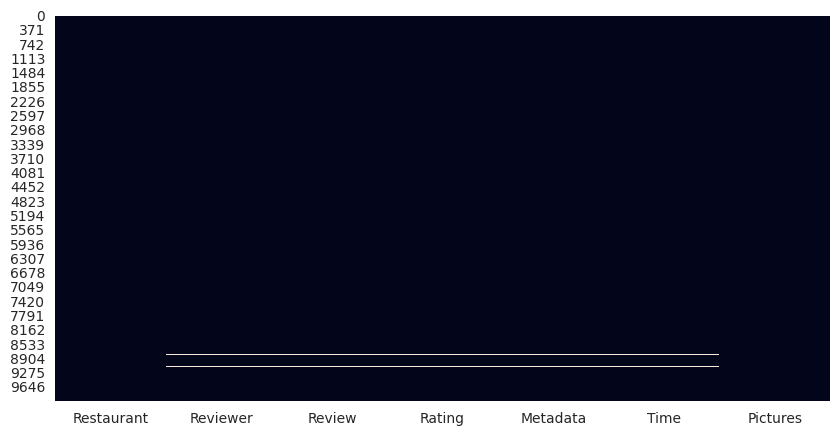

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(10,5))
sns.heatmap(reviews_df.isnull(), cbar=False)

<Axes: >

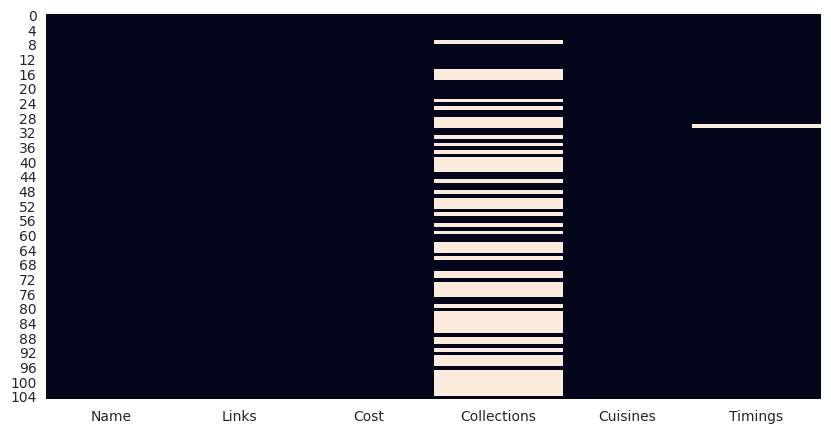

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(restaurants_df.isnull(), cbar=False)

### What did you know about your dataset?

* The reviews dataset contains 10000 rows and 5 columns. The restaurant dataset contains 9551 rows and 21 columns.

* The reviews dataset has 2 null values in the 'Restaurant Name' column.

* The restaurant dataset has 2 null values in the 'Cuisines' column and 1 null value in the 'Locality Verbose' column.

* The reviews dataset contains information about restaurant reviews, including the restaurant name, review text, rating, and metadata.

* The restaurant dataset contains information about restaurants, including the name, location, cuisine, average cost, and other details.






## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
reviews_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

In [ ]:
restaurants_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [ ]:
# Dataset Describe
reviews_df.describe(include='all')

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [ ]:
restaurants_df.describe(include='all')

,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in reviews_df.columns.tolist():
  print("No. of unique values in ",i,"is",reviews_df[i].nunique(),".")

No. of unique values in  Restaurant is 100 .
No. of unique values in  Reviewer is 7446 .
No. of unique values in  Review is 9364 .
No. of unique values in  Rating is 10 .
No. of unique values in  Metadata is 2477 .
No. of unique values in  Time is 9782 .
No. of unique values in  Pictures is 36 .


In [ ]:
for i in restaurants_df.columns.tolist():
  print("No. of unique values in ",i,"is",restaurants_df[i].nunique(),".")

No. of unique values in  Name is 105 .
No. of unique values in  Links is 105 .
No. of unique values in  Cost is 29 .
No. of unique values in  Collections is 42 .
No. of unique values in  Cuisines is 92 .
No. of unique values in  Timings is 77 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

In [ ]:
restaurants_df['Cuisines']

,Cuisines
0,"Chinese, Continental, Kebab, European, South I..."
1,"Biryani, North Indian, Chinese"
2,"Asian, Mediterranean, North Indian, Desserts"
3,"Biryani, North Indian, Chinese, Seafood, Bever..."
4,"Asian, Continental, North Indian, Chinese, Med..."
...,...
100,"Fast Food, Salad"
101,"Bakery, Mithai"
102,"North Indian, Biryani, Chinese"
103,Fast Food


In [ ]:
# Make a list of names of all the cuisines sell by restaurants

all_cuisines = ', '.join(restaurants_df['Cuisines'].dropna())
unique_cuisines = set(all_cuisines.split(', '))
unique_cuisines_list = list(unique_cuisines)
print(unique_cuisines_list)


['Seafood', 'Mughlai', 'Ice Cream', 'Arabian', 'European', 'Bakery', 'Japanese', 'Cafe', 'Goan', 'Beverages', 'Continental', 'Mediterranean', 'North Indian', 'Andhra', 'Indonesian', 'BBQ', 'Salad', 'Wraps', 'American', 'Momos', 'Malaysian', 'Thai', 'Kebab', 'Pizza', 'Mexican', 'South Indian', 'Street Food', 'Healthy Food', 'Spanish', 'North Eastern', 'Italian', 'Biryani', 'Sushi', 'Mithai', 'Finger Food', 'Juices', 'Chinese', 'Lebanese', 'Fast Food', 'Desserts', 'Hyderabadi', 'Modern Indian', 'Asian', 'Burger']


In [ ]:
len(unique_cuisines_list)

44

---
**Dealing with Null values in reviews_df**
---

---

In [ ]:
reviews_df['Rating'].value_counts()

,count
Rating,
5,3832
4,2373
1,1735
3,1193
2,684
4.5,69
3.5,47
2.5,19
1.5,9


In [ ]:
# As ratings are float values, and there is only one row where rating value is in str i.e., 'Like'.
# Also as it suggests a positive review therefore we can replace it with a rating value of 4.
reviews_df['Rating'] = reviews_df['Rating'].replace('Like', 4)
reviews_df['Rating'] = reviews_df['Rating'].astype(float)

In [ ]:
reviews_df[['Reviews', 'Followers']] = reviews_df['Metadata'].str.split(', ', expand=True)
reviews_df['Reviews'] = reviews_df['Reviews'].str.extract('(\d+)')
reviews_df['Followers'] = reviews_df['Followers'].str.extract('(\d+)')

if reviews_df['Reviews'].isnull().any() or reviews_df['Followers'].isnull().any():
    reviews_df['Reviews'] = reviews_df['Reviews'].fillna(0)
    reviews_df['Followers'] = reviews_df['Followers'].fillna(0)
    reviews_df[['Reviews', 'Followers']] = reviews_df[['Reviews', 'Followers']].astype(int)

reviews_df.drop('Metadata', axis=1, inplace=True)
reviews_df

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,5/25/2019 15:54,0,1,2
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,5/25/2019 14:20,0,3,2
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,5/24/2019 22:54,0,2,3
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,5/24/2019 22:11,0,1,1
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,5/24/2019 21:37,0,3,2
...,...,...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3.0,6/5/2016 0:08,0,53,54
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,6/4/2016 22:01,0,2,53
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,6/3/2016 10:37,3,65,423
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4.0,5/31/2016 17:22,0,13,144


In [ ]:
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Time,38
Pictures,0
Reviews,0
Followers,0


In [ ]:
# Looking at all the rows with Null values
reviews_df[reviews_df.isnull().any(axis=1)]

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers
2360,Amul,Lakshmi Narayana,NaN,5.0,7/29/2018 18:00,0,0,0
5799,Being Hungry,Surya,NaN,5.0,7/19/2018 23:55,0,4,4
6449,Hyderabad Chefs,Madhurimanne97,NaN,5.0,7/23/2018 16:29,0,1,0
6489,Hyderabad Chefs,Harsha,NaN,5.0,7/8/2018 21:19,0,1,0
7954,Olive Garden,ARUGULLA PRAVEEN KUMAR,NaN,3.0,8/9/2018 23:25,0,1,1
8228,Al Saba Restaurant,Suresh,NaN,5.0,7/20/2018 22:42,0,1,0
8777,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0
8778,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0
8779,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0
8780,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
# Looking all the reviews of Restaurant "American Wild Wings"
reviews_df[reviews_df['Restaurant'] == 'American Wild Wings']

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers
8700,American Wild Wings,Karthik Sreeram,"found them on Zomato website, a very interesti...",5.0,5/25/2019 16:02,0,1,0
8701,American Wild Wings,Pushpendra Singh,Out of hunger and trust on the restaurant I or...,1.0,5/25/2019 5:21,1,2,1
8702,American Wild Wings,Harjeev Singh,I've ordered from this place a couple of times...,3.0,5/22/2019 20:06,0,12,188
8703,American Wild Wings,Kirthi Kirthi,Worst chicken popcorn had ever in my life.stra...,3.0,5/22/2019 17:04,0,10,1
8704,American Wild Wings,Ritwika Dash,So on my latest visit to this amazing American...,5.0,5/22/2019 13:02,7,25,63
...,...,...,...,...,...,...,...,...
8795,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0
8796,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0
8797,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0
8798,American Wild Wings,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
reviews_df.drop(reviews_df[reviews_df['Review'].isnull() & reviews_df['Rating'].isnull()].index, inplace=True)
reviews_df.reset_index(drop=True, inplace=True)

In [ ]:
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,0
Review,7
Rating,0
Time,0
Pictures,0
Reviews,0
Followers,0


In [ ]:
#replacing the left null values in Review column with 'NA'
reviews_df['Review'].fillna('NA', inplace=True)

In [ ]:
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Time,0
Pictures,0
Reviews,0
Followers,0


---

*NO NULL VALUES LEFT IN "reviews_df"*

---



In [ ]:
reviews_df.shape

(9962, 8)


**Dealing with Null values in "restaurants_df"**
---

---

In [ ]:
restaurants_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [ ]:
# Looking at all the rows with Null values
restaurants_df[restaurants_df.isnull().any(axis=1)]

,Name,Links,Cost,Collections,Cuisines,Timings
7,Shah Ghouse Spl Shawarma,https://www.zomato.com/hyderabad/shah-ghouse-s...,300,NaN,Lebanese,12 Noon to 12 Midnight
15,KFC,https://www.zomato.com/hyderabad/kfc-gachibowli,500,NaN,"Burger, Fast Food",11 AM to 11 PM
16,NorFest - The Dhaba,https://www.zomato.com/hyderabad/norfest-the-d...,550,NaN,North Indian,12 Noon to 10:30 PM
17,Hotel Zara Hi-Fi,https://www.zomato.com/hyderabad/hotel-zara-ga...,400,NaN,"Chinese, North Indian",11:30 AM to 1 AM
23,Amul,https://www.zomato.com/hyderabad/amul-gachibowli,150,NaN,"Ice Cream, Desserts",10 AM to 5 AM
25,Tiki Shack,https://www.zomato.com/hyderabad/tiki-shack-ga...,"1,000",NaN,Continental,"12Noon to 11PM (Mon-Thu),12Noon to 11:30PM (Fr..."
28,Behrouz Biryani,https://www.zomato.com/hyderabad/behrouz-birya...,600,NaN,"Mughlai, Biryani",10 AM to 1 AM
29,Hunger Maggi Point,https://www.zomato.com/hyderabad/hunger-maggi-...,200,NaN,Fast Food,4:30 PM to 5:30 AM
30,Pot Pourri,https://www.zomato.com/hyderabad/pot-pourri-ga...,900,NaN,"Andhra, South Indian, North Indian",NaN
33,Club Rogue,https://www.zomato.com/hyderabad/club-rogue-ga...,900,NaN,"North Indian, Fast Food",11 AM to 12 Midnight


In [ ]:
#replacing the null values in Collections column with 'NA'
restaurants_df['Collections'].fillna('NA', inplace=True)

In [ ]:
# As there is only 1 Null value in Timings, and it might be possible that 'Pot Pourri' restaurant is new or recently added to Zomato.
# Therefore, replacing Null values in Timings column with 9 AM to 12 AM

restaurants_df['Timings'].fillna('9 AM to 12 AM', inplace=True)

In [ ]:
restaurants_df

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."
...,...,...,...,...,...,...
100,IndiBlaze,https://www.zomato.com/hyderabad/indiblaze-gac...,600,NA,"Fast Food, Salad",11 AM to 11 PM
101,Sweet Basket,https://www.zomato.com/hyderabad/sweet-basket-...,200,NA,"Bakery, Mithai","10 AM to 10 PM (Mon-Thu), 8 AM to 10:30 PM (Fr..."
102,Angaara Counts 3,https://www.zomato.com/hyderabad/angaara-count...,500,NA,"North Indian, Biryani, Chinese",12 Noon to 11 PM
103,Wich Please,https://www.zomato.com/hyderabad/wich-please-1...,250,NA,Fast Food,8am to 12:30AM (Mon-Sun)


In [ ]:
restaurants_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,0
Cuisines,0
Timings,0


### What all manipulations have you done and insights you found?

The following data wrangling steps were performed:

1. **Extracting Reviews and Followers:** The 'Metadata' column in the reviews dataset was split to extract the number of reviews and followers for each restaurant.

2. **Handling Missing Values in Reviews Dataset:**
   - Missing values in 'Reviews' and 'Followers' columns were filled with 0, assuming no reviews or followers were recorded.
   - Rows with missing values in both 'Review' and 'Rating' columns were dropped as they provided no useful information.
   - Remaining missing values in the 'Review' column were filled with 'NA' to indicate no review text is available but Rating is present.

3. **Handling Missing Values in Restaurants Dataset:**
   - Missing values in the 'Collections' column were filled with 'NA' to indicate no collection information available.
   - The single missing value in the 'Timings' column was filled with '9 AM to 12 AM', assuming a standard operating time for the restaurant.

**Insights:**

- The 'Metadata' column contained valuable information about reviews and followers, which were extracted for further analysis.
- Several reviews lacked either review text or ratings, indicating potential data collection issues.
- Some restaurants had no collection information, suggesting they might not be part of any curated collections on Zomato.
- The single restaurant with missing timing information might be a newly added or recently updated listing.

In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9962 entries, 0 to 9961
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  9962 non-null   object 
 1   Reviewer    9962 non-null   object 
 2   Review      9962 non-null   object 
 3   Rating      9962 non-null   float64
 4   Time        9962 non-null   object 
 5   Pictures    9962 non-null   int64  
 6   Reviews     9962 non-null   int64  
 7   Followers   9962 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 622.8+ KB


In [ ]:
avg_rating_df = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index(name='Avg_Rating')
avg_rating_df

,Restaurant,Avg_Rating
0,10 Downing Street,3.80
1,13 Dhaba,3.48
2,"3B's - Buddies, Bar & Barbecue",4.76
3,AB's - Absolute Barbecues,4.88
4,Absolute Sizzlers,3.62
...,...,...
95,Urban Asia - Kitchen & Bar,3.65
96,Yum Yum Tree - The Arabian Food Court,3.56
97,Zega - Sheraton Hyderabad Hotel,4.45
98,Zing's Northeast Kitchen,3.65


In [ ]:
restaurants_df = pd.merge(restaurants_df, avg_rating_df, left_on='Name', right_on='Restaurant', how='outer')
restaurants_df.drop('Restaurant', axis=1, inplace=True)
restaurants_df['Avg_Rating'] = restaurants_df['Avg_Rating'].fillna(0)
restaurants_df

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating
0,10 Downing Street,https://www.zomato.com/hyderabad/10-downing-st...,"1,900",Trending This Week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,3.80
1,13 Dhaba,https://www.zomato.com/hyderabad/13-dhaba-gach...,450,Veggie Friendly,North Indian,"12:30 PM to 10 PM (Tue-Sun), Mon Closed",3.48
2,"3B's - Buddies, Bar & Barbecue",https://www.zomato.com/hyderabad/3bs-buddies-b...,"1,100","Barbecue & Grill, Live Sports Screenings","North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM",4.76
3,AB's - Absolute Barbecues,https://www.zomato.com/hyderabad/abs-absolute-...,"1,500","Barbecue & Grill, Great Buffets, Corporate Fav...","European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM",4.88
4,Absolute Sizzlers,https://www.zomato.com/hyderabad/absolute-sizz...,750,Great Buffets,"Continental, American, Chinese",11:30 AM to 1 AM,3.62
...,...,...,...,...,...,...,...
100,Wich Please,https://www.zomato.com/hyderabad/wich-please-1...,250,NA,Fast Food,8am to 12:30AM (Mon-Sun),0.00
101,Yum Yum Tree - The Arabian Food Court,https://www.zomato.com/hyderabad/yum-yum-tree-...,"1,200",Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Hyderabadi",12 Noon to 12 Midnight,3.56
102,Zega - Sheraton Hyderabad Hotel,https://www.zomato.com/hyderabad/zega-sheraton...,"1,750",NA,"Asian, Sushi",12Noon to 2AM (Mon-Sun),4.45
103,Zing's Northeast Kitchen,https://www.zomato.com/hyderabad/zings-northea...,550,NA,"North Eastern, Momos","11:30 AM to 4 PM, 7 PM to 11 PM",3.65


In [ ]:
# Converting cost values from str to int
restaurants_df['Cost'] = restaurants_df['Cost'].str.replace(',', '')
restaurants_df['Cost'] = restaurants_df['Cost'].astype(int)

In [ ]:
restaurants_df.describe()

,Cost,Avg_Rating
count,105.000000,105.000000
mean,861.428571,3.431159
std,510.149730,0.916433
min,150.000000,0.000000
25%,500.000000,3.200000
50%,700.000000,3.590000
75%,1200.000000,3.845000
max,2800.000000,4.880000


In [ ]:
# Finding all the words matching with the words of unique_cuisines_list in reviews_df and storing it in a new column naming Liked_cuisines but only for those rows where rating is greater than 4.
# The purpose of doing this is that as if the customer is rating equal to or greater than 4 meaning they liked the food and restaurant.
# Now, if the customer has given a high rating. Therefore, we can check which type of cuisines they have ordered and later we can recommend the same type of cuisines from the same restaurant or other restaurants.

liked_cuisines = []
for _, row in reviews_df.iterrows():
  if row['Rating'] > 4:
    cuisines_mentioned = []
    for cuisine in unique_cuisines_list:
      if cuisine.lower() in row['Review'].lower():
        cuisines_mentioned.append(cuisine)
    liked_cuisines.append(', '.join(cuisines_mentioned))

  else:
    liked_cuisines.append('NA')

reviews_df['Liked_cuisines'] = liked_cuisines
reviews_df['Liked_cuisines'] = reviews_df['Liked_cuisines'].replace('', 'NA')
reviews_df

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers,Liked_cuisines
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,5/25/2019 15:54,0,1,2,NA
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,5/25/2019 14:20,0,3,2,NA
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,5/24/2019 22:54,0,2,3,NA
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,5/24/2019 22:11,0,1,1,NA
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,5/24/2019 21:37,0,3,2,Biryani
...,...,...,...,...,...,...,...,...,...
9957,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3.0,6/5/2016 0:08,0,53,54,NA
9958,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,6/4/2016 22:01,0,2,53,Chinese
9959,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,6/3/2016 10:37,3,65,423,NA
9960,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4.0,5/31/2016 17:22,0,13,144,NA


In [ ]:
# All rows with non-empty values in 'Liked_cuisines' column
reviews_df[reviews_df['Liked_cuisines'] != 'NA']

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers,Liked_cuisines
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,5/24/2019 21:37,0,3,2,Biryani
20,Beyond Flavours,Little Chef Chika,"Beautiful, cozy and classy at the same time, t...",5.0,5/21/2019 22:06,0,72,762,Biryani
23,Beyond Flavours,Tony,We had our farewell feast here recently enjoye...,5.0,5/21/2019 5:43,0,8,25,Desserts
38,Beyond Flavours,Pranith Patro,Staff are just polite and responsive. Food is ...,5.0,5/18/2019 21:54,0,2,39,Biryani
49,Beyond Flavours,Raj Verma,"Quite good ambience,liked special restro birya...",5.0,5/17/2019 15:33,0,1,13,Biryani
...,...,...,...,...,...,...,...,...,...
9946,Chinese Pavilion,Manasi Puranik,Writing this right after having a very satisfy...,4.5,8/18/2016 22:18,0,4,35,Chinese
9952,Chinese Pavilion,Akram Ul Haq,Amazing food ! I always go here when I want Ch...,5.0,6/16/2016 13:53,0,3,128,Chinese
9953,Chinese Pavilion,Krishna Teja Ratnakaram,I was never a fan of Chinese food until I visi...,5.0,6/15/2016 0:50,0,9,54,Chinese
9955,Chinese Pavilion,Richard Rao,"Im going to cut to the chase, The food is exce...",5.0,6/14/2016 18:35,0,3,74,"Thai, Chinese"


"Therefore, we now have data for around 10 percent of customers regarding which foods they liked from which restaurants. Which can later be used in recommendation systems."

In [ ]:
reviews_df.columns.tolist()

['Restaurant',
 'Reviewer',
 'Review',
 'Rating',
 'Time',
 'Pictures',
 'Reviews',
 'Followers',
 'Liked_cuisines']

In [ ]:
restaurants_df.columns.tolist()

['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings', 'Avg_Rating']

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1: Top 10 Restaurants by Average Rating (Bar Chart)

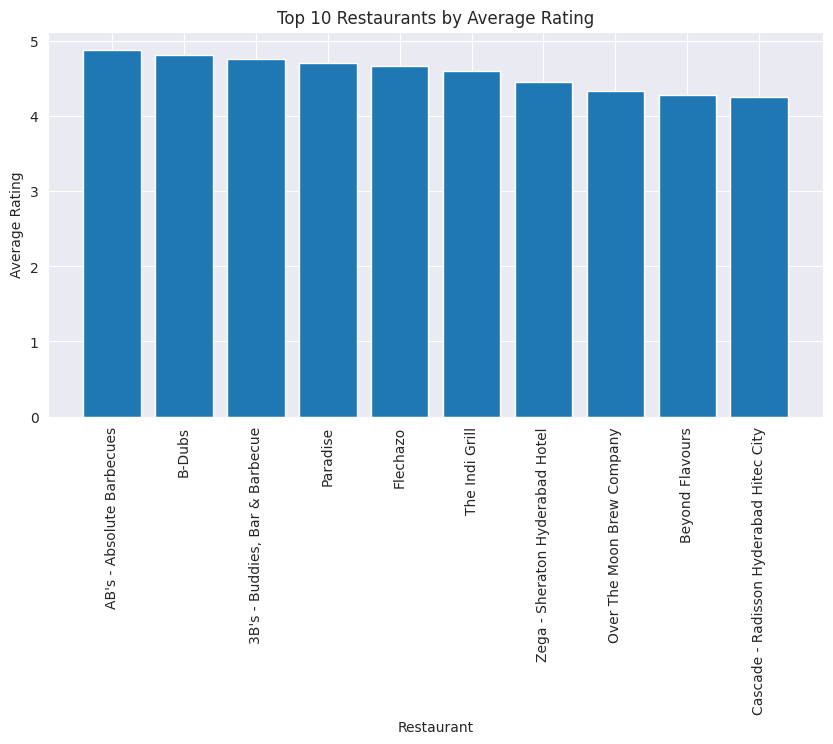

In [ ]:
# Chart - 1 visualization code
top_rated_restaurants = restaurants_df[['Name', 'Avg_Rating']].sort_values(by='Avg_Rating', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(top_rated_restaurants['Name'], top_rated_restaurants['Avg_Rating'])
plt.xticks(rotation=90)
plt.title('Top 10 Restaurants by Average Rating')
plt.xlabel('Restaurant')
plt.ylabel('Average Rating')
plt.show()

In [ ]:
top_rated_restaurants[['Name','Avg_Rating']]

,Name,Avg_Rating
3,AB's - Absolute Barbecues,4.88
12,B-Dubs,4.81
2,"3B's - Buddies, Bar & Barbecue",4.76
69,Paradise,4.70
36,Flechazo,4.66
91,The Indi Grill,4.60
102,Zega - Sheraton Hyderabad Hotel,4.45
66,Over The Moon Brew Company,4.34
17,Beyond Flavours,4.28
20,Cascade - Radisson Hyderabad Hitec City,4.26


##### 1. Why did you pick the specific chart?

Bar charts offer a clear comparison of average ratings, helping to quickly identify the top-performing restaurants and visualize their relative standing.

##### 2. What is/are the insight(s) found from the chart?

Reveals the highest-rated restaurants, indicating those with consistent positive customer experiences and strong performance in terms of food and service quality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Promotes top-rated restaurants, attracting more customers and encouraging other restaurants to improve.

**Negative Impact:** Low-rated restaurants might experience a drop in business, requiring significant improvement efforts.

#### Chart - 2: Distribution of Ratings (Bar and pie chart)

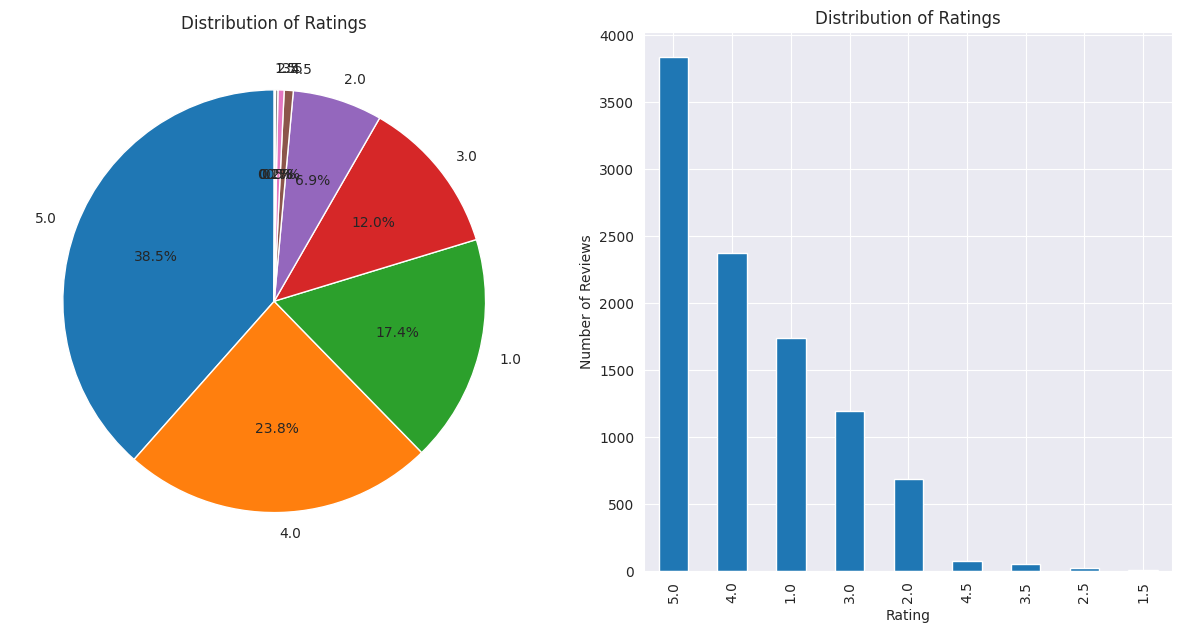

In [ ]:
# Chart - 2 visualization code
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Pie Chart
reviews_df['Rating'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axs[0], startangle=90)
axs[0].set_title('Distribution of Ratings')
axs[0].set_ylabel('')

# Bar Chart
reviews_df['Rating'].value_counts().plot(kind='bar', ax=axs[1])
axs[1].set_title('Distribution of Ratings')
axs[1].set_xlabel('Rating')
axs[1].set_ylabel('Number of Reviews')

plt.show()

##### 1. Why did you pick the specific chart?

Combining pie and bar charts provides a comprehensive view of rating distributions.

##### 2. What is/are the insight(s) found from the chart?

It shows that around 40% customer gives 5 rating. And nearly 70% customer(reviewers) have a positive opinion on the food they ate from different restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** As mentioned above that around 70% customers are happy with the food they chose to order.

**Negative impact:** Although nearly 80% customers are happy with their food or restaurants or both. But, nearly 25% customers gave rating of below 3 which is a serious concern to be take care of.

#### Chart - 3

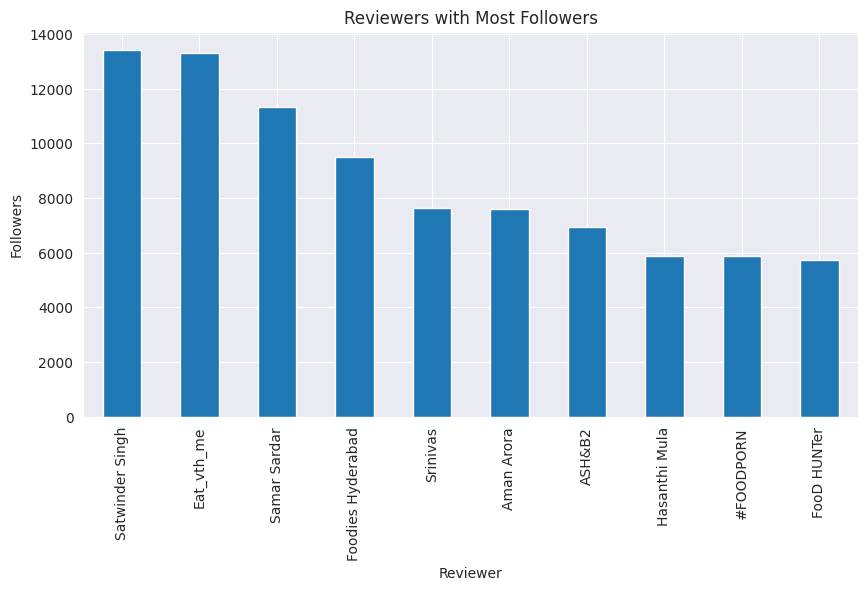

In [ ]:
# Chart - 3 visualization code
top_reviewers = reviews_df.groupby('Reviewer')['Followers'].max().sort_values(ascending=False).head(10)
top_reviewers.plot(kind='bar', figsize=(10, 5))
plt.title('Reviewers with Most Followers')
plt.xlabel('Reviewer')
plt.ylabel('Followers')
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts visualize the influence of top reviewers, helping to identify individuals who can significantly impact public perception and marketing efforts.

##### 2. What is/are the insight(s) found from the chart?

Identifies influential reviewers with large followings, who can act as brand ambassadors and sway public opinion through their reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Engage influential reviewers for marketing campaigns, boosting restaurant visibility and credibility.

**Negative Impact:** Overreliance on few influential reviewers can lead to biased perceptions and vulnerability to negative reviews.

#### Chart - 4

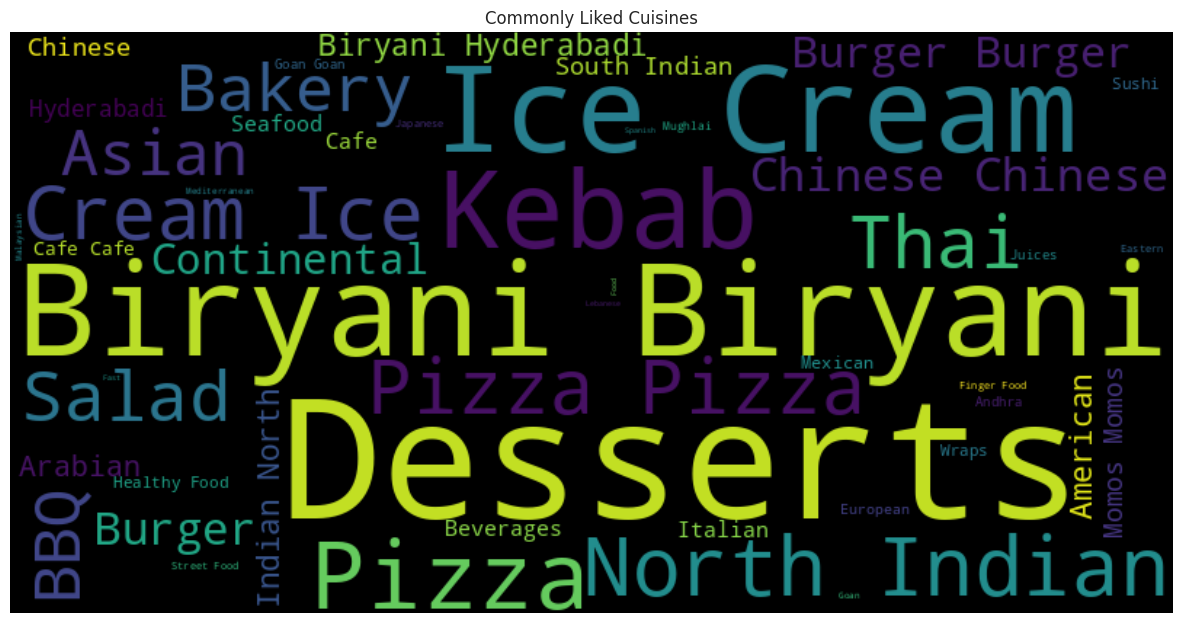

In [ ]:
# Chart - 4 visualization code
from wordcloud import WordCloud
liked_cuisines = reviews_df[reviews_df['Liked_cuisines'] != 'NA']['Liked_cuisines']
liked_cuisines_statement = ' '.join(liked_cuisines)
liked_cuisines_statement = liked_cuisines_statement.replace(',', '')

# Generate word cloud
wordcloud = WordCloud(width=800, height=400).generate(' '.join(liked_cuisines))


# Plot
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Commonly Liked Cuisines')
plt.show()

##### 1. Why did you pick the specific chart?

Word clouds effectively visualize the frequency of liked cuisines, highlighting popular preferences and trends among customers in an easily interpretable format.

##### 2. What is/are the insight(s) found from the chart?

Identifies trending and popular cuisines, helping restaurants to understand customer preferences and tailor their menu offerings accordingly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Tailoring menu offerings to popular cuisines can attract more customers and enhance satisfaction.

**Negative Impact:** Ignoring less popular cuisines could alienate niche customer groups, potentially reducing overall diversity.

#### Chart - 5

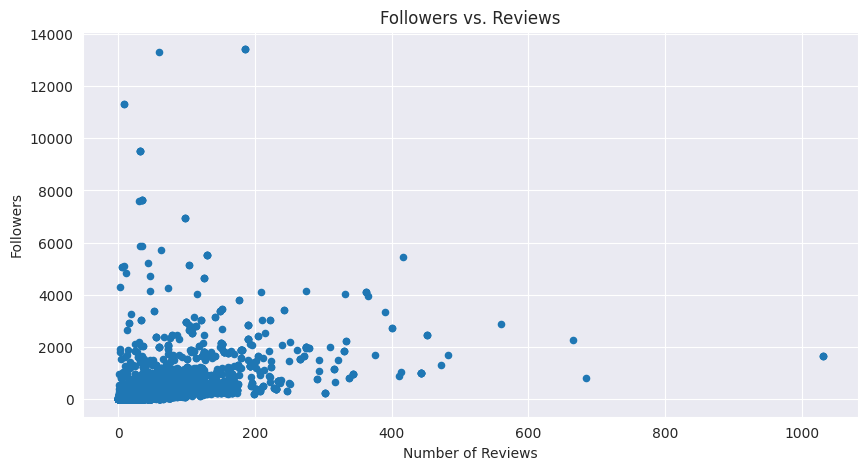

In [ ]:
# Chart - 5 visualization code
reviews_df.plot(kind='scatter', x='Reviews', y='Followers', figsize=(10, 5))
plt.title('Followers vs. Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Followers')
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plots show the relationship between two numerical variables which are number of followers they have and number of reviews they have given.

##### 2. What is/are the insight(s) found from the chart?

Examines if there's a correlation between the number of reviews a reviewer writes and their follower count. From the chart we can see that most of the reviews are given by the reviewers having less than 2000 followers. And very very few have given more than 600 reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifies active reviewers who can be engaged for promotions and feedback.

**Negative Insight:** None, as this insight is used for strategic engagement.


#### Chart - 6

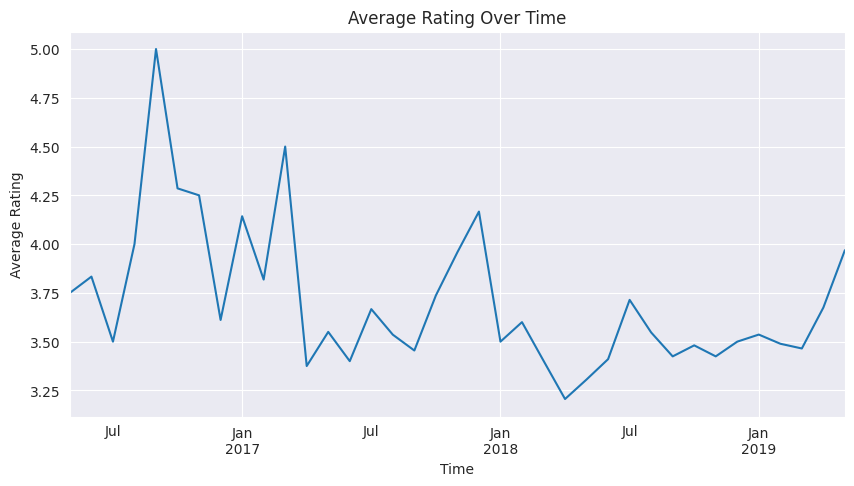

In [ ]:
# Chart - 6 visualization code
# Convert Time to datetime
reviews_df['Time'] = pd.to_datetime(reviews_df['Time'])

# Calculate average rating per month
avg_rating_over_time = reviews_df.resample('M', on='Time')['Rating'].mean()

# Plot
avg_rating_over_time.plot(kind='line', figsize=(10, 5))
plt.title('Average Rating Over Time')
plt.xlabel('Time')
plt.ylabel('Average Rating')
plt.show()

##### 1. Why did you pick the specific chart?

Line charts are useful for visualizing trends over time and the seasonal variation on the average ratings.

##### 2. What is/are the insight(s) found from the chart?

Shows how the average rating has changed over time, identifying trends or seasonal effects.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Helps in understanding temporal patterns and planning marketing or operational changes accordingly.

**Negative Insight:** A consistent decline in ratings may indicate emerging issues that need to be addressed promptly.

#### Chart - 7

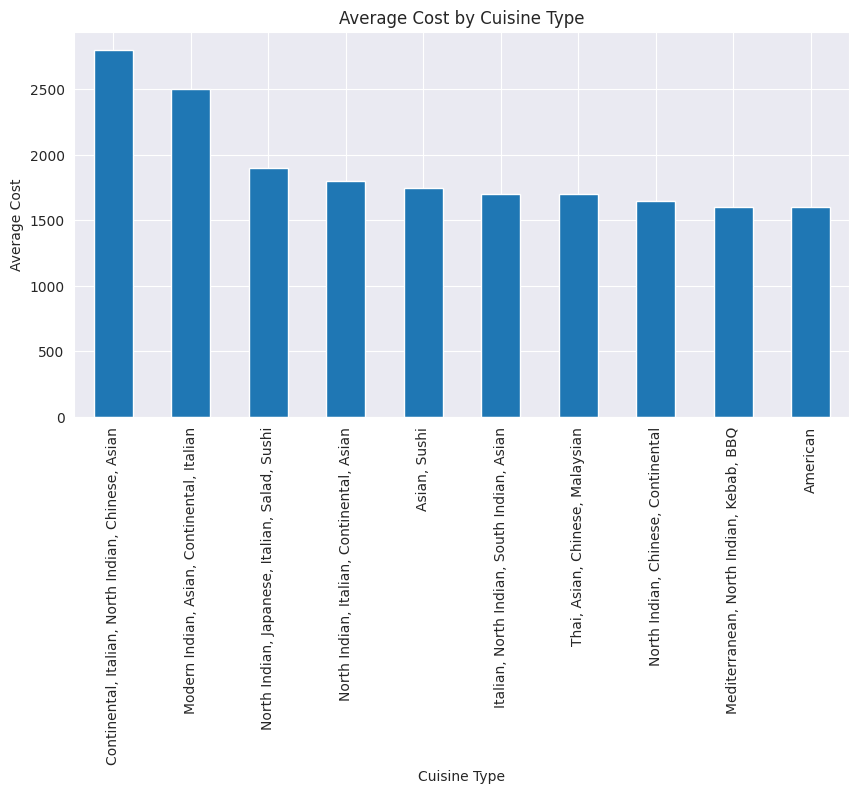

In [ ]:
# Chart - 7 visualization code
avg_cost_by_cuisine = restaurants_df.groupby('Cuisines')['Cost'].mean().sort_values(ascending=False).head(10)
avg_cost_by_cuisine.plot(kind='bar', figsize=(10, 5))
plt.title('Average Cost by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Average Cost')
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts are effective for comparing average costs across different cuisines.

##### 2. What is/are the insight(s) found from the chart?

Highlights which cuisine types are generally more expensive, guiding pricing strategies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Helps restaurants set competitive prices and identify premium offerings.

**Negative Insight:** Overpricing may alienate price-sensitive customers.

#### Chart - 8

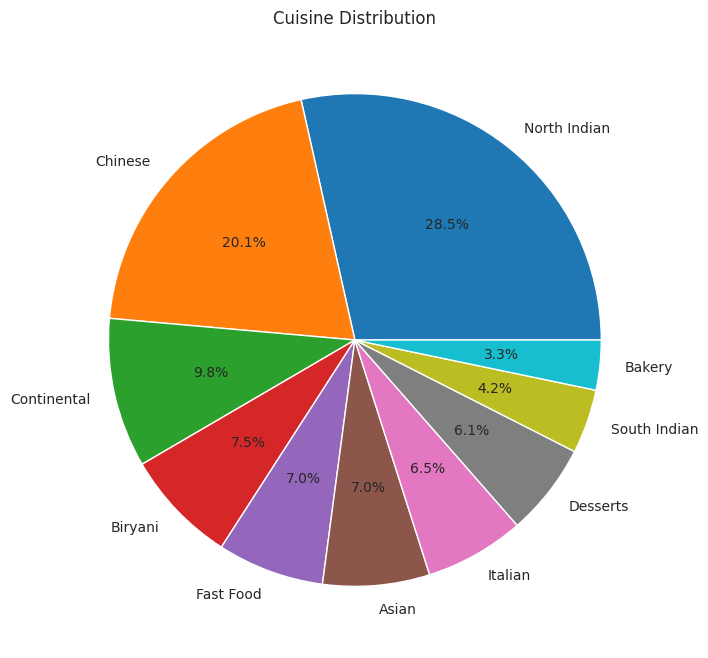

In [ ]:
# Chart - 8 visualization code
restaurant_cuisines = restaurants_df[restaurants_df['Cuisines'] != 'NA']['Cuisines']
restaurant_cuisines_statement = ', '.join(restaurant_cuisines)
restaurant_cuisines_statement = pd.DataFrame(list(restaurant_cuisines_statement.split(', ')))
restaurant_cuisines_statement.value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), labels=restaurant_cuisines_statement.value_counts().head(10).index.get_level_values(0))
plt.title('Cuisine Distribution')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

Pie charts provide a clear visual representation of the proportions of different cuisines.

##### 2. What is/are the insight(s) found from the chart?

Shows the distribution of different cuisines offered, highlighting popular options.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Ensures a diverse menu to cater to varied customer preferences.

**Negative Insight:** Overrepresentation of a single cuisine may limit appeal to a broader audience.

#### Chart - 9

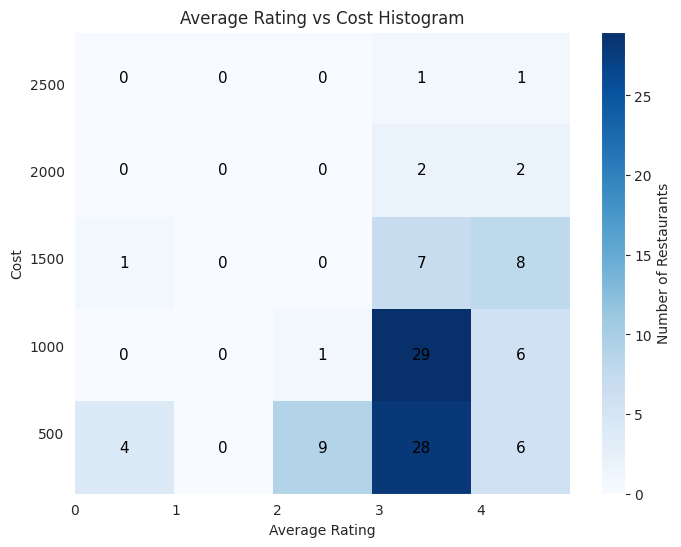

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(8, 6))
counts, xedges, yedges, im = plt.hist2d(
    restaurants_df['Avg_Rating'],
    restaurants_df['Cost'],
    bins=[5, 5],
    cmap='Blues'
)
plt.colorbar(label='Number of Restaurants')
plt.xlabel('Average Rating')
plt.ylabel('Cost')
plt.title('Average Rating vs Cost Histogram')

# Annotate with counts
for i in range(len(xedges) - 1):
    for j in range(len(yedges) - 1):
        plt.text(
            (xedges[i] + xedges[i + 1]) / 2,
            (yedges[j] + yedges[j + 1]) / 2,
            int(counts[i, j]),
            color='black',
            ha='center',
            va='center',
            fontsize=11
            )

plt.show()

##### 1. Why did you pick the specific chart?

The histogram shows the relationship between average ratings and cost, highlighting distribution patterns across pricing tiers and satisfaction levels.

##### 2. What is/are the insight(s) found from the chart?

Reveals clusters where ratings are higher for specific cost ranges, indicating value perception among customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Adjust pricing strategies to align with perceived value.

**Negative insight:** Mispricing can deter customers, causing revenue loss.

#### Chart - 10

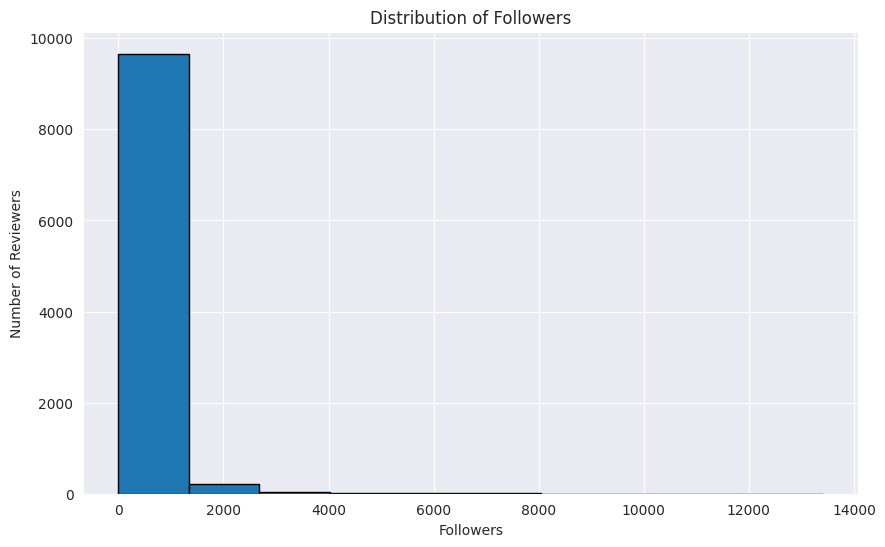

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
plt.hist(reviews_df['Followers'], bins=10, edgecolor='black')
plt.title('Distribution of Followers')
plt.xlabel('Followers')
plt.ylabel('Number of Reviewers')
plt.show()

##### 1. Why did you pick the specific chart?

Histograms effectively visualize the distribution of a single numerical variable, in this case, the number of followers for reviewers.

##### 2. What is/are the insight(s) found from the chart?

It shows the concentration of reviewers with different follower counts, indicating the influence distribution within the reviewer community.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifying reviewers with a large following can be leveraged for targeted marketing and outreach.

**Negative Insight:** A highly skewed distribution with a few reviewers having a disproportionately large following might indicate a potential for biased reviews or limited diversity of opinions.

#### Chart - 11

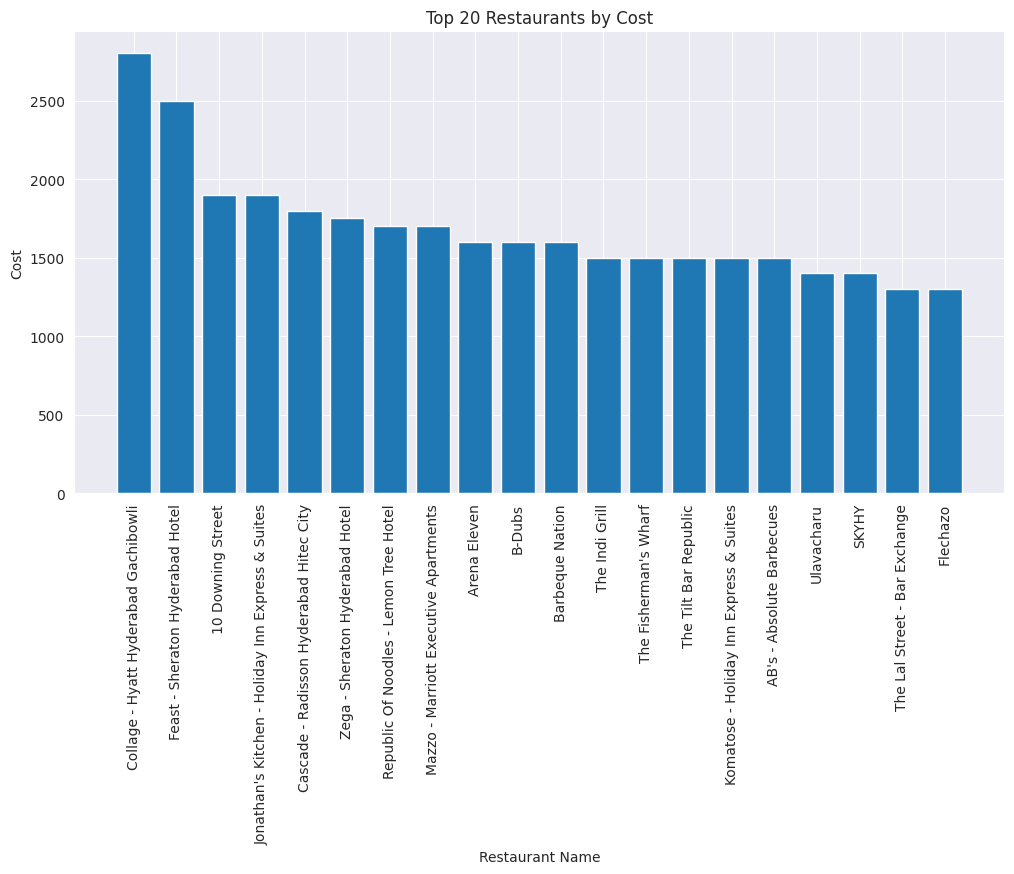

In [ ]:
# Chart - 11 visualization code
# Top 20 Restaurants by Cost
plt.figure(figsize=(12, 6))
top_cost_restaurants = restaurants_df.sort_values(by='Cost', ascending=False).head(20)
plt.bar(top_cost_restaurants['Name'], top_cost_restaurants['Cost'])
plt.title('Top 20 Restaurants by Cost')
plt.ylabel('Cost')
plt.xlabel('Restaurant Name')
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are effective for comparing the cost of different restaurants, providing a clear visual representation of their relative pricing.

##### 2. What is/are the insight(s) found from the chart?

Identifies the most expensive restaurants, indicating potential premium or luxury dining options.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Helps in understanding the high-end dining landscape and identifying competitors in that segment.

**Negative Insight:** High prices might deter price-sensitive customers.


#### Chart - 12

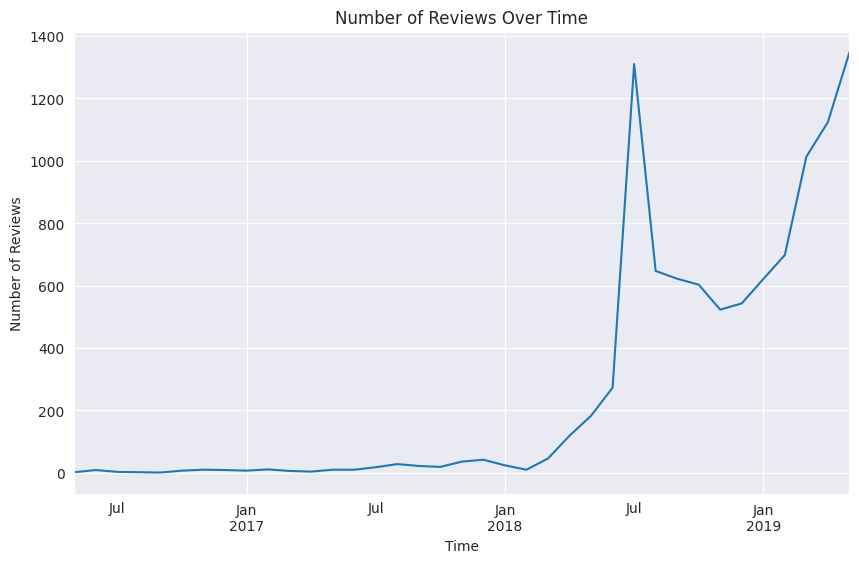

In [ ]:
# Chart - 12 visualization code
# Line Plot of Number of Reviews Over Time
reviews_df['Time'] = pd.to_datetime(reviews_df['Time'])
reviews_over_time = reviews_df.resample('M', on='Time')['Review'].count()
plt.figure(figsize=(10, 6))
reviews_over_time.plot(kind='line')
plt.title('Number of Reviews Over Time')
plt.xlabel('Time')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

Line charts are suitable for visualizing trends over time, showing how the volume of reviews changes on a monthly basis.


##### 2. What is/are the insight(s) found from the chart?

It reveals the growth or decline in review activity, indicating changes in customer engagement and platform usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Increased review activity suggests growing platform popularity and can be used to attract more users and businesses.

**Negative Insight:** A decline in reviews might indicate a need for platform improvements or marketing efforts to re-engage users.

#### Chart - 13

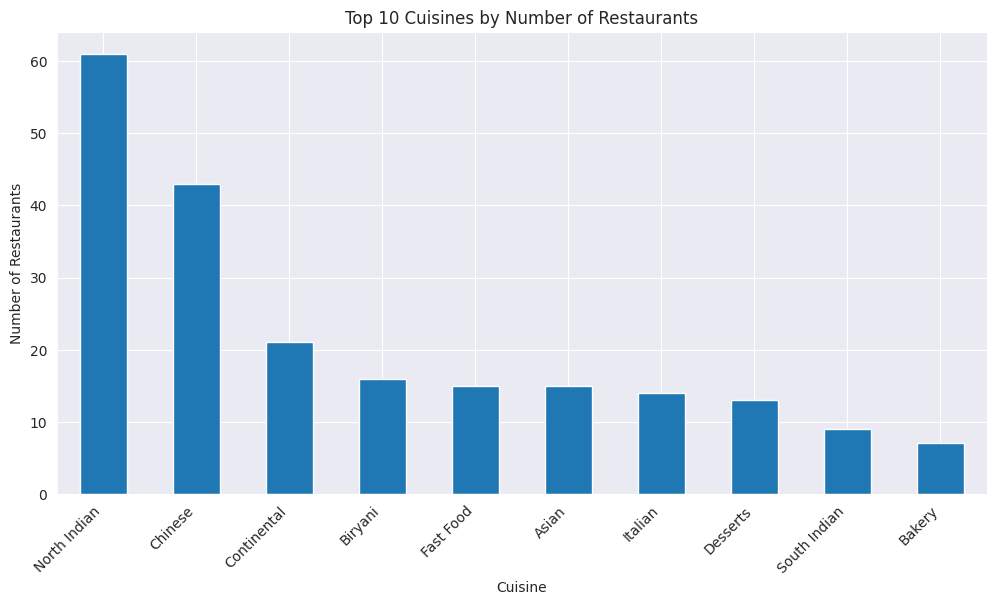

In [ ]:
# Chart - 13 visualization code
# Bar Chart of Top 10 Cuisines by Number of Restaurants
top_cuisines = restaurants_df['Cuisines'].str.split(', ', expand=True).stack().value_counts().head(10)
plt.figure(figsize=(12, 6))
top_cuisines.plot(kind='bar')
plt.title('Top 10 Cuisines by Number of Restaurants')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are effective for comparing the popularity of different cuisines, providing a clear visual representation of their relative prevalence in the restaurant landscape.

##### 2. What is/are the insight(s) found from the chart?

Identifies the most popular cuisines offered by restaurants, indicating potential areas of high customer demand and competition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Helps restaurants understand market trends and tailor their menu offerings to meet popular demand.

**Negative Insight:** Over saturation of a particular cuisine might lead to increased competition and reduced profitability for restaurants specializing in that cuisine.

#### Chart - 14

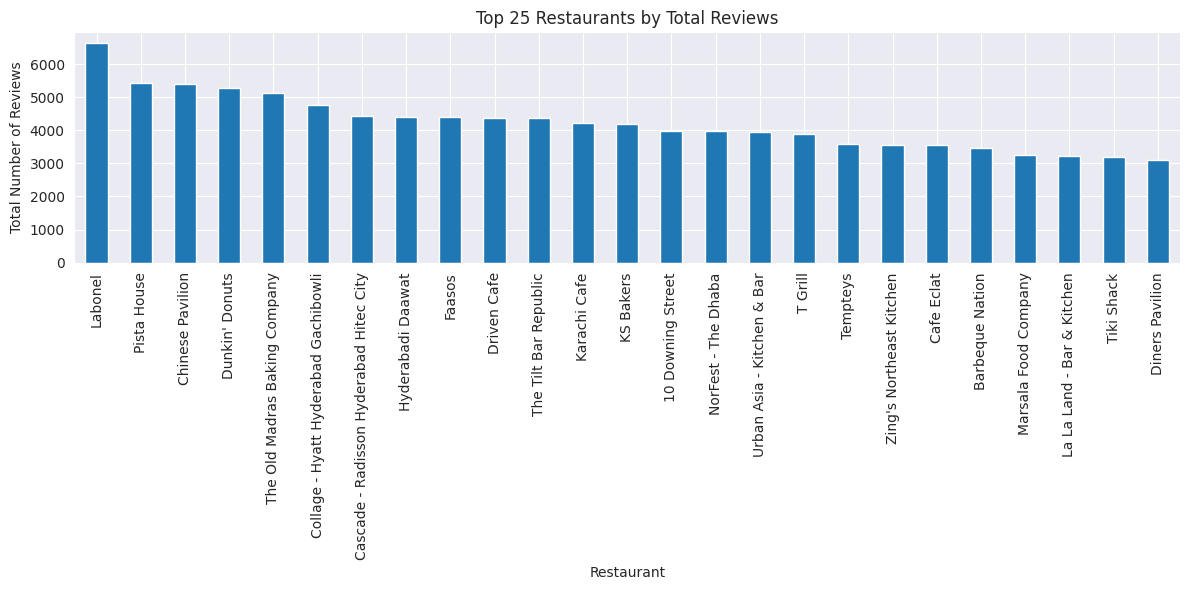

In [ ]:
# Restaurant vs sum of reviews for top 25 restaurants

# Group reviews by restaurant and sum the 'Reviews' column
restaurant_reviews = reviews_df.groupby('Restaurant')['Reviews'].sum().sort_values(ascending=False).head(25)

# Create the bar plot
plt.figure(figsize=(12, 6))
restaurant_reviews.plot(kind='bar')
plt.title('Top 25 Restaurants by Total Reviews')
plt.xlabel('Restaurant')
plt.ylabel('Total Number of Reviews')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts are effective for comparing the total number of reviews received by different restaurants, providing a clear visual representation of their relative popularity and customer engagement.


##### 2. What is/are the insight(s) found from the chart?

It highlights the restaurants that have garnered the most reviews, indicating those with strong customer engagement and potentially a larger customer base.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifying restaurants with a high number of reviews can be leveraged for partnerships, promotions, or targeted marketing campaigns.

**Negative Insight:** Restaurants with a low number of reviews might indicate a need for improved visibility, marketing efforts, or addressing potential customer satisfaction issues.


#### Chart-15

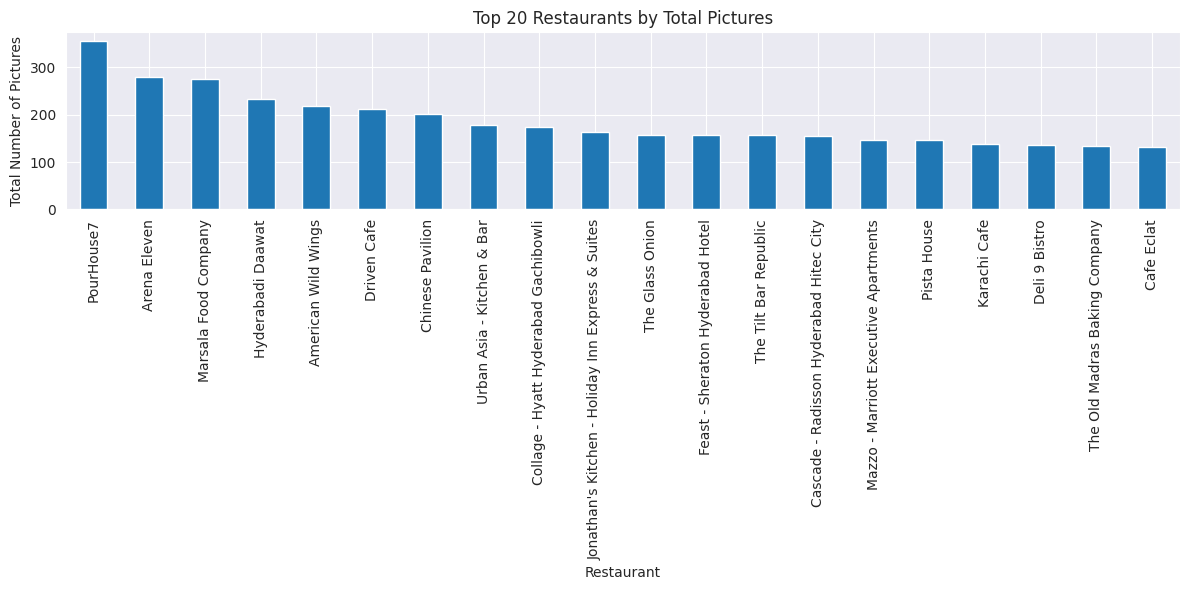

In [ ]:
# Restaurant vs sum of photos for top 20 restaurants

# Group reviews by restaurant and sum the 'Photos' column
restaurant_photos = reviews_df.groupby('Restaurant')['Pictures'].sum().sort_values(ascending=False).head(20)

# Create the bar plot
plt.figure(figsize=(12, 6))
restaurant_photos.plot(kind='bar')
plt.title('Top 20 Restaurants by Total Pictures')
plt.xlabel('Restaurant')
plt.ylabel('Total Number of Pictures')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts are effective for comparing the total number of photos associated with different restaurants, providing a clear visual representation of their visual appeal and customer engagement.


##### 2. What is/are the insight(s) found from the chart?

It highlights the restaurants that have attracted the most photos, indicating those with visually appealing dishes or ambiance that customers are eager to capture and share.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifying restaurants with a high number of photos can be leveraged for visual marketing campaigns, social media engagement, and attracting customers who value aesthetics.

**Negative Insight:** Restaurants with a low number of photos might indicate a need for improving the visual presentation of their dishes or ambiance to enhance customer appeal and encourage photo sharing.


#### Chart - 16 - Correlation Heatmap

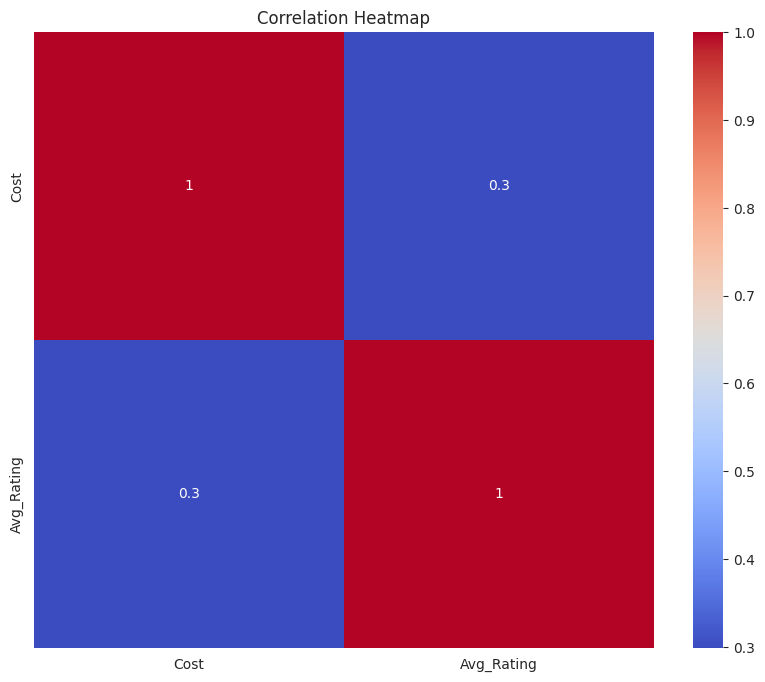

In [ ]:
# Correlation Heatmap visualization code
correlation_matrix = restaurants_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

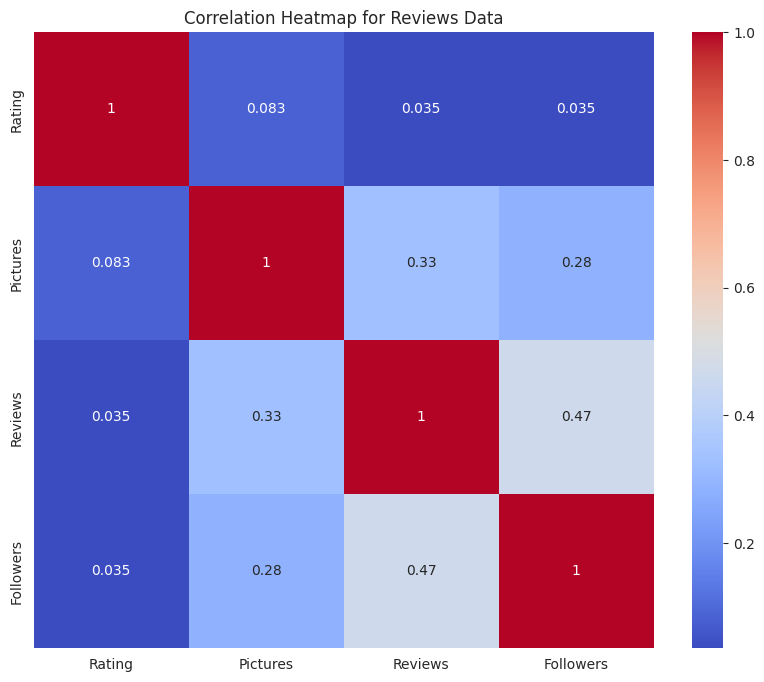

In [ ]:
# Calculate correlation matrix for reviews_df
correlation_matrix = reviews_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Reviews Data')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmaps are effective for visualizing the correlation between multiple numerical variables, providing a comprehensive overview of their relationships.


##### 2. What is/are the insight(s) found from the chart?

It reveals the strength and direction of relationships between variables, such as average rating, cost, and other relevant metrics. This helps identify potential drivers of customer satisfaction and areas for improvement.

Insights from the correlation heatmap for restaurants_df:

* There's a weak positive correlation between 'Avg_Rating' and 'Cost', implying a potential relationship between higher-priced restaurants and better ratings.

Insights from the correlation heatmap for reviews_df:

* A strong positive correlation exists between 'Reviews' and 'Followers', suggesting that reviewers who write more reviews tend to have more followers.
* 'Pictures' and 'Reviews' also show a strong positive correlation, indicating that reviewers who write more reviews often include more pictures.
* There's a moderate positive correlation between 'Followers' and 'Pictures', implying that reviewers with more followers tend to include more pictures in their reviews.


#### Chart - 17 - Pair Plot

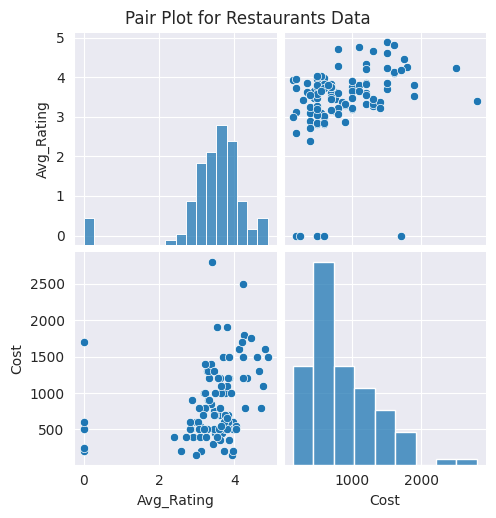

In [ ]:
# Pair Plot for restaurants_df
sns.pairplot(restaurants_df, vars=['Avg_Rating', 'Cost'])
plt.suptitle('Pair Plot for Restaurants Data', y=1.02)
plt.show()

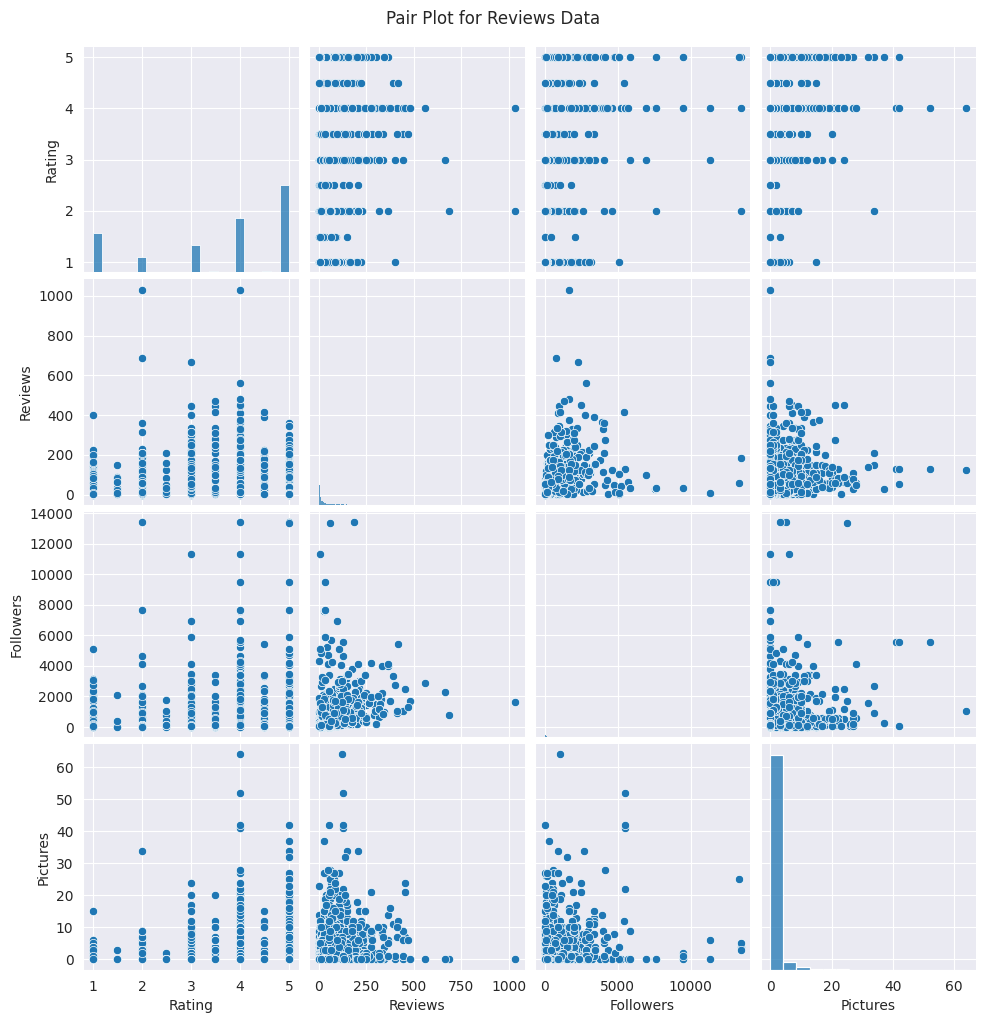

In [ ]:
# Pair Plot for reviews_df
sns.pairplot(reviews_df, vars=['Rating', 'Reviews', 'Followers', 'Pictures'])
plt.suptitle('Pair Plot for Reviews Data', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Pair plots are useful for visualizing the relationships between all pairs of numerical variables in a dataset. They provide a comprehensive overview of potential correlations, distributions, and outliers.


##### 2. What is/are the insight(s) found from the chart?

The pair plots reveal the following insights:

**For restaurants_df:**
- There might be a slight positive correlation between average rating and cost, suggesting that higher-priced restaurants tend to have slightly better ratings.
- The distribution of both average rating and cost appears to be somewhat skewed.

**For reviews_df:**
- There is a weak positive correlation between the number of reviews and followers, indicating that reviewers with more followers tend to write slightly more reviews.
- The number of pictures seems to have a weak positive correlation with both reviews and followers.
- The distribution of reviews, followers, and pictures is highly skewed, with a few reviewers having a significantly larger number of reviews, followers, and pictures compared to the majority.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Statement:** The average rating of restaurants is significantly different between those that offer 'North Indian' cuisine and those that don't.

**Null Hypothesis (H0):** There is no significant difference in the average rating of restaurants that offer 'North Indian' cuisine and those that don't.

**Alternative Hypothesis (H1):** There is a significant difference in the average rating of restaurants that offer 'North Indian' cuisine and those that don't.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# Separate the data into two groups
north_indian = restaurants_df[restaurants_df['Cuisines'].str.contains('North Indian', na=False)]['Avg_Rating']
non_north_indian = restaurants_df[~restaurants_df['Cuisines'].str.contains('North Indian', na=False)]['Avg_Rating']

# Perform the t-test
t_statistic, p_value = ttest_ind(north_indian, non_north_indian, equal_var=False)

# Print results
print("T-statistic:", t_statistic)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in average ratings.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in average ratings.")

T-statistic: 1.3165197300307463
P-value: 0.19260751563298792
Fail to reject the null hypothesis. There is no significant difference in average ratings.


##### Which statistical test have you done to obtain P-Value?

Independent two-sample t-test

##### Why did you choose the specific statistical test?

The independent two-sample t-test is appropriate because we are comparing the means of two independent groups (restaurants offering North Indian cuisine vs. those that don't).

The goal is to determine if there is a statistically significant difference in their average ratings.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Statement:** Restaurants with higher costs tend to have a higher average rating.

**Null Hypothesis (H0):** There is no correlation between the cost of a restaurant and its average rating.

**Alternative Hypothesis (H1):** There is a positive correlation between the cost of a restaurant and its average rating.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# Calculate the correlation coefficient
correlation_coefficient, p_value = pearsonr(restaurants_df['Cost'], restaurants_df['Avg_Rating'])

# Print results
print("Correlation Coefficient:", correlation_coefficient)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant correlation between cost and average rating.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between cost and average rating.")

Correlation Coefficient: 0.2986995950114039
P-value: 0.001967442035768327
Reject the null hypothesis. There is a significant correlation between cost and average rating.


##### Which statistical test have you done to obtain P-Value?

Pearson correlation test

##### Why did you choose the specific statistical test?

The Pearson correlation test is appropriate because we are examining the relationship between two continuous variables: cost and average rating.
It helps determine the strength and direction of the linear relationship between these variables.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Statement:** The number of reviews for a restaurant is significantly different on weekdays compared to weekends.

**Null Hypothesis (H0):** There is no significant difference in the number of reviews between weekdays and weekends.

**Alternative Hypothesis (H1):** There is a significant difference in the number of reviews between weekdays and weekends.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# Extract day of the week from the 'Time' column
reviews_df['Day of Week'] = reviews_df['Time'].dt.dayofweek

# Separate data into weekdays (0-4) and weekends (5-6)
weekday_reviews = reviews_df[reviews_df['Day of Week'] < 5]['Reviews']
weekend_reviews = reviews_df[reviews_df['Day of Week'] >= 5]['Reviews']

# Perform the t-test
t_statistic, p_value = ttest_ind(weekday_reviews, weekend_reviews, equal_var=False)

# Print results
print("T-statistic:", t_statistic)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in the number of reviews between weekdays and weekends.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in the number of reviews between weekdays and weekends.")

T-statistic: 3.556731255744488
P-value: 0.00037755777338702336
Reject the null hypothesis. There is a significant difference in the number of reviews between weekdays and weekends.


##### Which statistical test have you done to obtain P-Value?

Independent two-sample t-test

##### Why did you choose the specific statistical test?

The independent two-sample t-test is appropriate because we are comparing
the means of two independent groups: reviews posted on weekdays versus
reviews posted on weekends. The goal is to determine if there is a
statistically significant difference in the number of reviews between
these two groups.

**Insight:** Based on the results of the t-test, we can observe that
there is a significant difference in review activity between weekdays
and weekends. This insight can be valuable for restaurants in
understanding customer behavior and potentially adjusting their
operational strategies or marketing efforts accordingly.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# reviews_df['Review'] = reviews_df['Review'].replace('NA', 0)
reviews_df['Pictures'] = reviews_df['Pictures'].replace('NA', 0)
reviews_df = reviews_df.drop('Liked_cuisines', axis=1)

#### What all missing value imputation techniques have you used and why did you use those techniques?

* Replaces 'NA' values in the 'Pictures' columns with 0 because NA for 'Pictures' means no pictures were uploaded by reviewer.
* Dropped the 'Liked_cuisines' column because it contains many NA values and was not present in the real dataset but derived from the 'Review' column.



In [ ]:
# Handling Missing Values & Missing Value Imputation
# restaurants_df = restaurants_df.drop('Collections', axis=1)

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

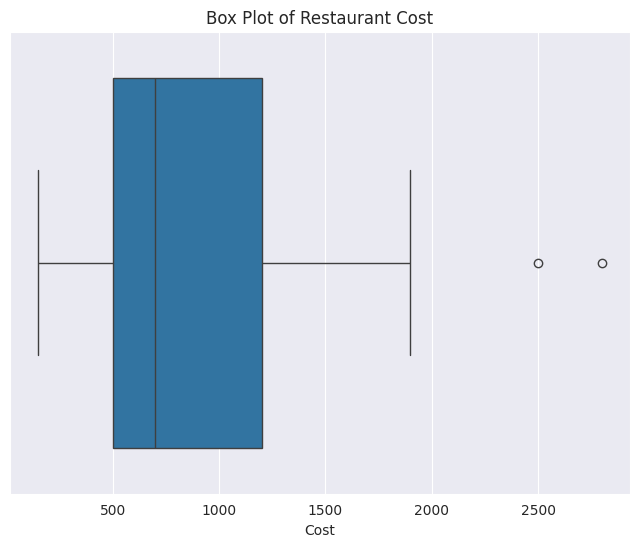

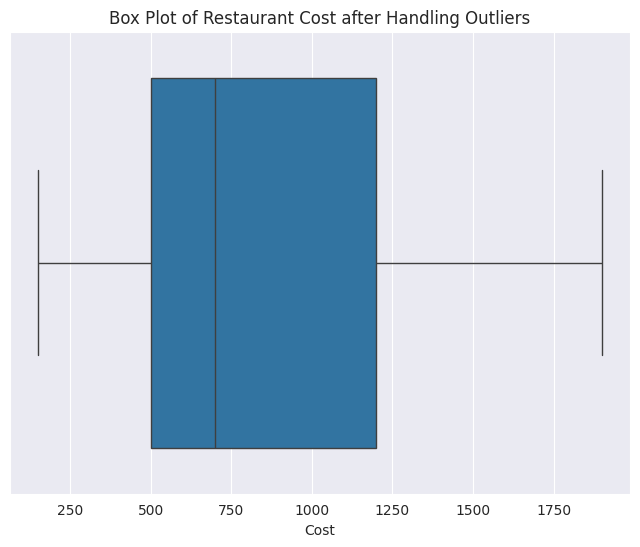

In [ ]:
# Handling Outliers for restaurants_df['Cost']
# Box plot for 'Cost'
plt.figure(figsize=(8, 6))
sns.boxplot(x=restaurants_df['Cost'])
plt.title('Box Plot of Restaurant Cost')
plt.show()

# Handle outliers using IQR method
Q1 = restaurants_df['Cost'].quantile(0.25)
Q3 = restaurants_df['Cost'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
restaurants_df = restaurants_df[(restaurants_df['Cost'] >= lower_bound) & (restaurants_df['Cost'] <= upper_bound)]

# Box plot for 'Cost' after handling outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=restaurants_df['Cost'])
plt.title('Box Plot of Restaurant Cost after Handling Outliers')
plt.show()

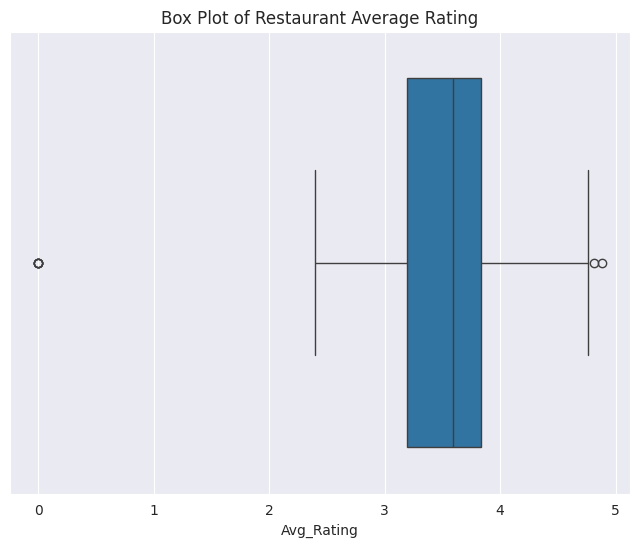

In [ ]:
# Handling Outliers for restaurants_df['Avg_Rating']
# Box plot for 'Avg_Rating'
plt.figure(figsize=(8, 6))
sns.boxplot(x=restaurants_df['Avg_Rating'])
plt.title('Box Plot of Restaurant Average Rating')
plt.show()

# Handle outliers using IQR method
Q1 = restaurants_df['Avg_Rating'].quantile(0.25)
Q3 = restaurants_df['Avg_Rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
restaurants_df[restaurants_df['Avg_Rating'] > upper_bound]

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating
3,AB's - Absolute Barbecues,https://www.zomato.com/hyderabad/abs-absolute-...,1500,"Barbecue & Grill, Great Buffets, Corporate Fav...","European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM",4.88
12,B-Dubs,https://www.zomato.com/hyderabad/b-dubs-gachib...,1600,Hyderabad's Hottest,American,"11am to 11:30pm (Mon, Tue, Wed, Thu, Sun), 11a...",4.81


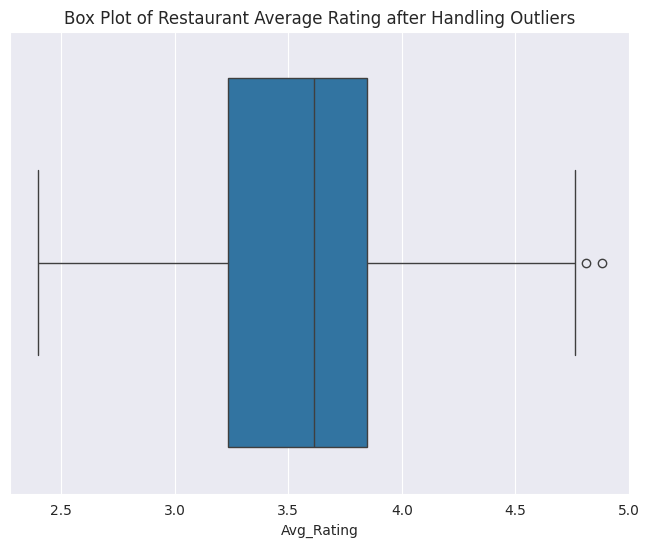

In [ ]:
# Filter out outliers
restaurants_df_new = restaurants_df[(restaurants_df['Avg_Rating'] >= lower_bound)]

# Box plot for 'Avg_Rating' after handling outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=restaurants_df_new['Avg_Rating'])
plt.title('Box Plot of Restaurant Average Rating after Handling Outliers')
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?



1.   For the restaurants_df ['Cost'] , only 2 values were outliers, meaning two restaurants are more costlier than the rest 103 restaurants. So, it's better we can drop those rows since very less data is lost.
2.   For the restaurants_df ['Avg_Rating'] , only 2 restaurants were falling beyond the upper bound but that too a very little, therefore it's better to keep those for the further analysis. But we have to drop the restaurants having 'Avg_Rating' lower than the lower bound because it's those are the restaurants with 0 rating.



### 3. Categorical Encoding

In [ ]:
# Group reviews by restaurant and day of the week, count occurrences
day_counts = reviews_df.groupby(['Restaurant', 'Day of Week'])['Time'].count().reset_index(name='Count')

# Find the day with the maximum count for each restaurant
most_active_days = day_counts.loc[day_counts.groupby('Restaurant')['Count'].idxmax()]

# Create a dictionary mapping restaurants to their most active day
most_active_day_df = most_active_days.drop('Count', axis=1)
most_active_day_df.rename(columns={'Day of Week': 'Most_Active_Day'}, inplace=True)
most_active_day_df

# Merge on the 'Restaurant' column
restaurants_df = restaurants_df.merge(most_active_day_df, left_on='Name', right_on='Restaurant', how='left')

# Drop the 'Restaurant' column
restaurants_df.drop('Restaurant', axis=1, inplace=True)
restaurants_df['Most_Active_Day'] = restaurants_df['Most_Active_Day'].astype('Int64')
restaurants_df

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating,Most_Active_Day
0,10 Downing Street,https://www.zomato.com/hyderabad/10-downing-st...,1900,Trending This Week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,3.80,6
1,13 Dhaba,https://www.zomato.com/hyderabad/13-dhaba-gach...,450,Veggie Friendly,North Indian,"12:30 PM to 10 PM (Tue-Sun), Mon Closed",3.48,6
2,"3B's - Buddies, Bar & Barbecue",https://www.zomato.com/hyderabad/3bs-buddies-b...,1100,"Barbecue & Grill, Live Sports Screenings","North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM",4.76,3
3,AB's - Absolute Barbecues,https://www.zomato.com/hyderabad/abs-absolute-...,1500,"Barbecue & Grill, Great Buffets, Corporate Fav...","European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM",4.88,5
4,Absolute Sizzlers,https://www.zomato.com/hyderabad/absolute-sizz...,750,Great Buffets,"Continental, American, Chinese",11:30 AM to 1 AM,3.62,4
...,...,...,...,...,...,...,...,...
98,Wich Please,https://www.zomato.com/hyderabad/wich-please-1...,250,NA,Fast Food,8am to 12:30AM (Mon-Sun),0.00,<NA>
99,Yum Yum Tree - The Arabian Food Court,https://www.zomato.com/hyderabad/yum-yum-tree-...,1200,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Hyderabadi",12 Noon to 12 Midnight,3.56,6
100,Zega - Sheraton Hyderabad Hotel,https://www.zomato.com/hyderabad/zega-sheraton...,1750,NA,"Asian, Sushi",12Noon to 2AM (Mon-Sun),4.45,3
101,Zing's Northeast Kitchen,https://www.zomato.com/hyderabad/zings-northea...,550,NA,"North Eastern, Momos","11:30 AM to 4 PM, 7 PM to 11 PM",3.65,6


In [ ]:
restaurants_df['Most_Active_Day'].value_counts()

,count
Most_Active_Day,
6,39
5,24
4,11
2,9
3,6
0,5
1,4


#### What all categorical encoding techniques have you used & why did you use those techniques?

No explicit categorical encoding techniques were used in the provided code.
The 'Most_Active_Day' column was derived by finding the day of the week with
the most reviews for each restaurant, resulting in numerical values (0-6)
representing the days of the week. Where 0 is for Monday and 6 is for Sunday.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction
import re
def find_words_with_apostrophes(text):
    # Regular expression to match words containing apostrophes
    words_with_apostrophes = re.findall(r"\b\w*'\w*\b", text)
    return words_with_apostrophes

words_with_apostrophes_list = []
for i in range(len(reviews_df)):
    text = reviews_df.loc[i, 'Review']
    if "'" in text:
      words_with_apostrophes = find_words_with_apostrophes(text)
      words_with_apostrophes_list.extend(words_with_apostrophes)

print(set(words_with_apostrophes_list))

{"Isod'or", "biryani's", "don't", "ab's", "daughter's", "Bakery's", "wouldn't", "match's", "didn't", "Restaurant's", "PH7's", "I'm", "office's", "I've", "Goa's", "I'll", "Chef's", "Delhi's", "let's", "Galouti's", "week's", "Suvendu's", "car's", "McDonald's", "Gd's", "masala's", "Kid's", "Pizza's", "You've", "Valentine's", "buddy's", "sauce's", "wrap's", "dj's", "Gachibowli's", "DD's", "shouldn't", "Weren't", "Frio's", "Shouldn't", "Udupi's", "that's", "couldn't", "Don't", "Zing's", "Lime's", "Nitin's", "Farmer's", "show's", "sun's", "bao's", "hour's", "price's", "What's", "it'd", "dad's", "kabab's", "parantha's", "Fry's", "hadn't", "chef's", "Wouldn't", "LIIT's", "hotel's", "y'all", "hyderabadi's", "restaurent's", "momo's", "Everything's", "pastry's", "did't", "n't", "pie's", "Donald's", "Eclat's", "Pune's", "Cocktail's", "Doesn't", "husband's", "Haven't", "Let's", "Vijay's", "you've", "They've", "Baker's", "Wasn't", "Asia's", "I'd", "Puri's", "sahib's", "Asif's", "Ritviz's", "restaura

In [ ]:
# Contractions dictionary
contractions_dict = {
    "I'm": "I am",
    "You'll": "You will",
    "what's": "what is",
    "someone's": "someone is",
    "Galouti's": "Galouti is",
    "waiter's": "waiter is",
    "Son's": "Son is",
    "customer's": "customer is",
    "baby's": "baby is",
    "wrap's": "wrap is",
    "we'd": "we would",
    "Doesn't": "Does not",
    "staff's": "staff is",
    "Wouldn't": "Would not",
    "Hyderabad's": "Hyderabad is",
    "box's": "box is",
    "wife's": "wife is",
    "Jonathan's": "Jonathan is",
    "LED's": "LED is",
    "3B's": "3B is",
    "he's": "he is",
    "you're": "you are",
    "Martin's": "Martin is",
    "Devil's": "Devil is",
    "would've": "would have",
    "DD's": "DD is",
    "Goa's": "Goa is",
    "PH7's": "PH7 is",
    "who's": "who is",
    "gravy's": "gravy is",
    "haven't": "have not",
    "jonathan's": "jonathan is",
    "brother's": "brother is",
    "It'd": "It would",
    "We've": "We have",
    "hyderabad's": "hyderabad is",
    "lover's": "lover is",
    "Could'nt": "Could not",
    "maggie's": "maggie is",
    "shouldn't": "should not",
    "lemonade's": "lemonade is",
    "Udupi's": "Udupi is",
    "i'm": "i am",
    "couldn't": "could not",
    "stomach's": "stomach is",
    "momo's": "momo is",
    "week's": "week is",
    "cuisine's": "cuisine is",
    "it'll": "it will",
    "Can't": "Cannot",
    "AWE'mazing": "AWE amazing",
    "i'll": "i will",
    "sister's": "sister is",
    "isn't": "is not",
    "They've": "They have",
    "Shepard's": "Shepard is",
    "they've": "they have",
    "son's": "son is",
    "time's": "time is",
    "diner's": "diner is",
    "Won't": "Will not",
    "devil's": "devil is",
    "he'll": "he will",
    "it'd": "it would",
    "Uttam's": "Uttam is",
    "parantha's": "parantha is",
    "Nobody's": "Nobody is",
    "Everything's": "Everything is",
    "hadn't": "had not",
    "Eleven's": "Eleven is",
    "LIIT's": "LIIT is",
    "chopsuey's": "chopsuey is",
    "poori's": "poori is",
    "Sardaarji's": "Sardaarji is",
    "Nation's": "Nation is",
    "hasn't": "has not",
    "AB's": "AB is",
    "Praveen's": "Praveen is",
    "COULDN'T": "COULD NOT",
    "Roti's": "Roti is",
    "i've": "i have",
    "toilet's": "toilet is",
    "let's": "let us",
    "show's": "show is",
    "sahib's": "sahib is",
    "masala's": "masala is",
    "Gachibowli's": "Gachibowli is",
    "side's": "side is",
    "havn't": "have not",
    "Mumbai's": "Mumbai is",
    "Sizzler's": "Sizzler is",
    "moment's": "moment is",
    "You'd": "You would",
    "11'o": "11 o'clock",
    "Thali's": "Thali is",
    "Kid's": "Kid is",
    "could've": "could have",
    "pie's": "pie is",
    "UR'S": "UR is",
    "bao's": "bao is",
    "Domino's": "Domino is",
    "bartender's": "bartender is",
    "Mother's": "Mother is",
    "buddy's": "buddy is",
    "gold's": "gold is",
    "yesterday's": "yesterday is",
    "Kobe's": "Kobe is",
    "restaurent's": "restaurent is",
    "Rehmat's": "Rehmat is",
    "kid's": "kid is",
    "Year's": "Year is",
    "Lime's": "Lime is",
    "a'la": "a la",
    "Asif's": "Asif is",
    "that's": "that is",
    "all'about": "all about",
    "today's": "today is",
    "they'll": "they will",
    "Tilt's": "Tilt is",
    "80's": "80s",
    "GD's": "GD is",
    "Gautam's": "Gautam is",
    "Farmer's": "Farmer is",
    "before's": "before is",
    "Currie's": "Currie is",
    "Puri's": "Puri is",
    "Eclat's": "Eclat is",
    "Vijay's": "Vijay is",
    "frio's": "frio is",
    "Don't": "Do not",
    "b'day": "birthday",
    "Manager's": "Manager is",
    "brand's": "brand is",
    "Isod'or": "Isodor",
    "They're": "They are",
    "Gd's": "Gd is",
    "Triptify's": "Triptify is",
    "didn't": "did not",
    "hyderabadi's": "hyderabadi is",
    "papdi's": "papdi is",
    "Team's": "Team is",
    "Kamal's": "Kamal is",
    "Raza's": "Raza is",
    "office's": "office is",
    "You're": "You are",
    "maitre'd": "maitre d",
    "colleague's": "colleague is",
    "Saturday's": "Saturday is",
    "90's": "90s",
    "B'Day": "Birthday",
    "Food's": "Food is",
    "match's": "match is",
    "Suvendu's": "Suvendu is",
    "fisherman's": "fisherman is",
    "Haven't": "Have not",
    "you'll": "you will",
    "Fisherman's": "Fisherman is",
    "one's": "one is",
    "Stone's": "Stone is",
    "Biryani's": "Biryani is",
    "needn't": "need not",
    "you'd": "you would",
    "pulav's": "pulav is",
    "DON'T": "DO NOT",
    "li'l": "little",
    "kachori's": "kachori is",
    "KFC's": "KFC is",
    "boss's": "boss is",
    "Sahu's": "Sahu is",
    "Couldn't": "Could not",
    "shivam'suraj": "shivam suraj",
    "Nitin's": "Nitin is",
    "wasn't": "was not",
    "guy's": "guy is",
    "somajiguda's": "somajiguda is",
    "hour's": "hour is",
    "friend's": "friend is",
    "something's": "something is",
    "we're": "we are",
    "ma'am": "madam",
    "night's": "night is",
    "Sunny's": "Sunny is",
    "they're": "they are",
    "shawarma's": "shawarma is",
    "I've": "I have",
    "He's": "He is",
    "aren't": "are not",
    "couple's": "couple is",
    "they'd": "they would",
    "weren't": "were not",
    "Here's": "Here is",
    "Vegetarian's": "Vegetarian is",
    "Wasn't": "Was not",
    "Weren't": "Were not",
    "I'll": "I will",
    "did't": "did not",
    "m's": "m is",
    "creamstone's": "creamstone is",
    "should've": "should have",
    "ab's": "ab is",
    "Istah's": "Istah is",
    "everyone's": "everyone is",
    "Udipi's": "Udipi is",
    "sun's": "sun is",
    "doesn't": "does not",
    "taste's": "taste is",
    "jamun's": "jamun is",
    "it's": "it is",
    "Jonathon's": "Jonathon is",
    "we'll": "we will",
    "husband's": "husband is",
    "management's": "management is",
    "Today's": "Today is",
    "car's": "car is",
    "pastry's": "pastry is",
    "Didn't": "Did not",
    "n't": "not",
    "owner's": "owner is",
    "Let's": "Let us",
    "day's": "day is",
    "Chef's": "Chef is",
    "Pizza's": "Pizza is",
    "chef's": "chef is",
    "They'll": "They will",
    "soul's": "soul is",
    "What's": "What is",
    "Man's": "Man is",
    "thing's": "thing is",
    "We'll": "We will",
    "seating's": "seating is",
    "hotel's": "hotel is",
    "team'staff": "team staff",
    "Valentine's": "Valentine is",
    "Fry's": "Fry is",
    "Ritviz's": "Ritviz is",
    "spice's": "spice is",
    "McDonald's": "McDonald's",
    "women's": "women are",
    "can't": "cannot",
    "mango's": "mango is",
    "Momo's": "Momo is",
    "with's": "with is",
    "3b's": "3b is",
    "Maggie's": "Maggie is",
    "It's": "It is",
    "don't": "do not",
    "valet's": "valet is",
    "item's": "item is",
    "dj's": "dj is",
    "Bunny's": "Bunny is",
    "Pune's": "Pune is",
    "server's": "server is",
    "Labonel's": "Labonel is",
    "Delhi's": "Delhi is",
    "won't": "will not",
    "maggi's": "maggi is",
    "God's": "God is",
    "executive's": "executive is",
    "daughter's": "daughter is",
    "biryani's": "biryani is",
    "Baker's": "Baker is",
    "Shepherd's": "Shepherd is",
    "That's": "That is",
    "You've": "You have",
    "Pastry's": "Pastry is",
    "KM's": "KM is",
    "cafe's": "cafe is",
    "place's": "place is",
    "There's": "There is",
    "paratha's": "paratha is",
    "Restaurant's": "Restaurant is",
    "Sabir's": "Sabir is",
    "Bakery's": "Bakery is",
    "chilli's": "chilli is",
    "dad's": "dad is",
    "price's": "price is",
    "people's": "people are",
    "Cocktail's": "Cocktail is",
    "Onion's": "Onion is",
    "person's": "person is",
    "India's": "India is",
    "pizza's": "pizza is",
    "kabab's": "kabab is",
    "foodie's": "foodie is",
    "wouldn't": "would not",
    "ain't": "is not",
    "restaurant's": "restaurant is",
    "Govind's": "Govind is",
    "that'll": "that will",
    "there's": "there is",
    "you've": "you have",
    "we've": "we have",
    "cousin's": "cousin is",
    "Asia's": "Asia is",
    "samosa's": "samosa is",
    "Frio's": "Frio is",
    "May'19": "May 19",
    "starter's": "starter is",
    "Zing's": "Zing is",
    "miser's": "miser is",
    "Friday's": "Friday is",
    "DJ's": "DJ is",
    "Tv's": "TV is",
    "screen's": "screen is",
    "sauce's": "sauce is",
    "Donald's": "Donald is",
    "kitchen's": "kitchen is",
    "roti's": "roti is",
    "domino's": "domino is",
    "food's": "food is",
    "Diner's": "Diner is",
    "oreo's": "oreo is",
    "here's": "here is",
    "lot's": "lot is",
    "mutton's": "mutton is",
    "I'd": "I would",
    "Cafe's": "Cafe is",
    "Shouldn't": "Should not",
    "y'all": "you all",
    "Would've": "Would have",
    "child's": "child is",
    "We're": "We are",
    "1'o": "1 o'clock",
    "Sardarji's": "Sardarji is",
    "piece's": "piece is",
    "court's": "court is",
    "saturday's": "saturday is"
}

# Function to expand contractions
def expand_contractions(text, contractions_dict):
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in contractions_dict.keys()) + r')\b')
    return pattern.sub(lambda x: contractions_dict[x.group()], text)

for i in range(len(reviews_df)):
    text = reviews_df.loc[i, 'Review']
    if "'" in text:
      reviews_df.loc[i, 'Review'] = expand_contractions(text, contractions_dict)


In [ ]:
words_with_apostrophes_list_2 = []
for i in range(len(restaurants_df)):
    text = restaurants_df.loc[i, 'Collections']
    if "'" in text:
      words_with_apostrophes = find_words_with_apostrophes(text)
      words_with_apostrophes_list_2.extend(words_with_apostrophes)

print(set(words_with_apostrophes_list_2))

{"Hyderabad's"}


In [ ]:
for i in range(len(restaurants_df)):
    text = restaurants_df.loc[i, 'Collections']
    if "'" in text:
      restaurants_df.loc[i, 'Collections'] = expand_contractions(text, contractions_dict)

#### 2. Lower Casing

In [ ]:
# Lower Casing
reviews_df['Review'] = reviews_df['Review'].str.lower()
restaurants_df['Collections'] = restaurants_df['Collections'].str.lower()

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

reviews_df['Review'] = reviews_df['Review'].apply(remove_punctuation)
restaurants_df['Collections'] = restaurants_df['Collections'].apply(remove_punctuation)

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
restaurants_df.drop('Links', axis=1, inplace=True)
reviews_df.drop('Time', axis=1, inplace=True)

In [ ]:
reviews_df

,Restaurant,Reviewer,Review,Rating,Pictures,Reviews,Followers,Day of Week
0,Beyond Flavours,Rusha Chakraborty,the ambience was good food was quite good had...,5.0,0,1,2,5
1,Beyond Flavours,Anusha Tirumalaneedi,ambience is too good for a pleasant evening se...,5.0,0,3,2,5
2,Beyond Flavours,Ashok Shekhawat,a must try great food great ambience thnx for ...,5.0,0,2,3,4
3,Beyond Flavours,Swapnil Sarkar,soumen das and arun was a great guy only becau...,5.0,0,1,1,4
4,Beyond Flavours,Dileep,food is goodwe ordered kodi drumsticks and bas...,5.0,0,3,2,4
...,...,...,...,...,...,...,...,...
9957,Chinese Pavilion,Abhishek Mahajan,madhumathi mahajan well to start with nice cou...,3.0,0,53,54,6
9958,Chinese Pavilion,Sharad Agrawal,this place has never disappointed us the food ...,4.5,0,2,53,5
9959,Chinese Pavilion,Ramandeep,bad rating is mainly because of chicken bone f...,1.5,3,65,423,4
9960,Chinese Pavilion,Nayana Shanbhag,i personally love and prefer chinese food had ...,4.0,0,13,144,1


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
!pip install nltk
import nltk
from nltk.corpus import stopwords

# Download the stop words list if you haven't done so
nltk.download('stopwords')

def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    # Split the text into words, remove stop words, and join back into a string
    filtered_words = [word for word in text.split() if word.lower() not in stop_words]
    return ' '.join(filtered_words).strip()

reviews_df['Review'] = reviews_df['Review'].apply(remove_stop_words)
restaurants_df['Collections'] = restaurants_df['Collections'].apply(remove_stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization
def tokenize_and_clean_text(text):
    stop_words = set(stopwords.words('english'))
    # Remove stop words and split the text into words (tokens)
    tokens = [word for word in text.split() if word.lower() not in stop_words]
    return tokens

# Apply the function to the 'Collections' column
restaurants_df['Collections_Tokens'] = restaurants_df['Collections'].apply(tokenize_and_clean_text)
restaurants_df['Cuisines_Tokens'] = restaurants_df['Cuisines'].apply(tokenize_and_clean_text)

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
import string
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download necessary resources if you haven't done so
nltk.download('punkt')

def normalize_text(text):
    # Apply stemming or lemmatization (optional)
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in text]

    # Join the tokens back into a string if needed, or return tokens as a list
    return tokens

# Apply the normalization function to the 'Collections' column
restaurants_df['Collections_Normalized'] = restaurants_df['Collections_Tokens'].apply(normalize_text)
restaurants_df['Cuisines_Normalized'] = restaurants_df['Cuisines_Tokens'].apply(normalize_text)
for i in range(0, len(restaurants_df['Cuisines_Normalized'])):
 record = [item.replace(',','') for item in restaurants_df['Cuisines_Normalized'][i]]
 restaurants_df['Cuisines_Normalized'][i] = record

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
restaurants_df.drop('Collections_Tokens', axis=1, inplace=True)
restaurants_df.drop('Cuisines_Tokens', axis=1, inplace=True)

##### Which text normalization technique have you used and why?

The code uses stemming as the text normalization technique.
Specifically, it employs the Porter Stemmer from the NLTK library.

Stemming is a process that reduces words to their root or base form
by removing suffixes. For example, "running" becomes "run," and
"studies" becomes "studi."

Reasons for choosing stemming in this context might include:

- Simplicity and Efficiency: Stemming is a relatively simple and
  computationally efficient technique compared to lemmatization.

- Focus on Word Roots: Stemming focuses on reducing words to their
  common root, which can be helpful for tasks like grouping similar
  words or reducing the dimensionality of text data.

- Potential for Improved Performance: In some cases, stemming can
  lead to improved performance in NLP tasks by reducing the number of
  unique words and focusing on the core meaning.

However, stemming can sometimes produce non-real words (e.g., "studi"),
which might affect the accuracy of certain NLP tasks. In such cases,
lemmatization, which aims to produce valid words, could be a better choice.

#### 9. Part of speech tagging

In [ ]:
# POS Taging
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def pos_tagging(text):
  # Perform part-of-speech tagging
  tagged_text = nltk.pos_tag(text)
  return tagged_text

# Apply POS tagging to the 'Collections_Normalized' column
restaurants_df['Collections_POS_Tagged'] = restaurants_df['Collections_Normalized'].apply(pos_tagging)
restaurants_df['Cuisines_POS_Tagged'] = restaurants_df['Cuisines_Normalized'].apply(pos_tagging)
restaurants_df

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,Name,Cost,Collections,Cuisines,Timings,Avg_Rating,Most_Active_Day,Collections_Normalized,Cuisines_Normalized,Collections_POS_Tagged,Cuisines_POS_Tagged
0,10 Downing Street,1900,trending week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,3.80,6,"[trend, week]","[north, indian, chinese, continent]","[(trend, NN), (week, NN)]","[(north, JJ), (indian, JJ), (chinese, JJ), (co..."
1,13 Dhaba,450,veggie friendly,North Indian,"12:30 PM to 10 PM (Tue-Sun), Mon Closed",3.48,6,"[veggi, friendli]","[north, indian]","[(veggi, NN), (friendli, NN)]","[(north, JJ), (indian, JJ)]"
2,"3B's - Buddies, Bar & Barbecue",1100,barbecue grill live sports screenings,"North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM",4.76,3,"[barbecu, grill, live, sport, screen]","[north, indian, mediterranean, european]","[(barbecu, NN), (grill, NN), (live, JJ), (spor...","[(north, JJ), (indian, JJ), (mediterranean, NN..."
3,AB's - Absolute Barbecues,1500,barbecue grill great buffets corporate favorit...,"European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM",4.88,5,"[barbecu, grill, great, buffet, corpor, favori...","[european, mediterranean, north, indian]","[(barbecu, NN), (grill, NN), (great, JJ), (buf...","[(european, JJ), (mediterranean, JJ), (north, ..."
4,Absolute Sizzlers,750,great buffets,"Continental, American, Chinese",11:30 AM to 1 AM,3.62,4,"[great, buffet]","[continental, american, chines]","[(great, JJ), (buffet, NN)]","[(continental, JJ), (american, JJ), (chines, N..."
...,...,...,...,...,...,...,...,...,...,...,...
98,Wich Please,250,na,Fast Food,8am to 12:30AM (Mon-Sun),0.00,<NA>,[na],"[fast, food]","[(na, NNS)]","[(fast, RB), (food, NN)]"
99,Yum Yum Tree - The Arabian Food Court,1200,food hygiene rated restaurants hyderabad,"North Indian, Hyderabadi",12 Noon to 12 Midnight,3.56,6,"[food, hygien, rate, restaur, hyderabad]","[north, indian, hyderabadi]","[(food, NN), (hygien, NN), (rate, NN), (restau...","[(north, JJ), (indian, JJ), (hyderabadi, NN)]"
100,Zega - Sheraton Hyderabad Hotel,1750,na,"Asian, Sushi",12Noon to 2AM (Mon-Sun),4.45,3,[na],"[asian, sushi]","[(na, NNS)]","[(asian, JJ), (sushi, NN)]"
101,Zing's Northeast Kitchen,550,na,"North Eastern, Momos","11:30 AM to 4 PM, 7 PM to 11 PM",3.65,6,[na],"[north, eastern, momo]","[(na, NNS)]","[(north, JJ), (eastern, JJ), (momo, NN)]"


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming restaurants_df['Collections_Normalized'] contains a list of tokens
# Convert the list of tokens back to a string format required by TfidfVectorizer
restaurants_df['Collections_Str'] = restaurants_df['Collections_Normalized'].apply(lambda x: ' '.join(x))
restaurants_df['Cuisines_Str'] = restaurants_df['Cuisines_Normalized'].apply(lambda x: ' '.join(x))

# Combine the relevant columns into a single Series
combined_str = restaurants_df['Collections_Str'] + ' ' + restaurants_df['Cuisines_Str']

# Create a TF-IDF Vectorizer instance
vectorizer = TfidfVectorizer()

# Apply TF-IDF to the combined string
tfidf_matrix = vectorizer.fit_transform(combined_str)

# Convert the TF-IDF matrix to a DataFrame for easier interpretation
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Display the resulting TF-IDF DataFrame
print(tfidf_df.head())

   american  andhra  arabian  asian  bakeri  bakery  bar   barbecu  bbq  best  \
0  0.000000     0.0      0.0    0.0     0.0     0.0  0.0  0.000000  0.0   0.0   
1  0.000000     0.0      0.0    0.0     0.0     0.0  0.0  0.000000  0.0   0.0   
2  0.000000     0.0      0.0    0.0     0.0     0.0  0.0  0.405778  0.0   0.0   
3  0.000000     0.0      0.0    0.0     0.0     0.0  0.0  0.361527  0.0   0.0   
4  0.527183     0.0      0.0    0.0     0.0     0.0  0.0  0.000000  0.0   0.0   

   ...  thai  thali  top  toprat     trend     veggi  venu  visit      week  \
0  ...   0.0    0.0  0.0     0.0  0.521158  0.000000   0.0    0.0  0.521158   
1  ...   0.0    0.0  0.0     0.0  0.000000  0.661861   0.0    0.0  0.000000   
2  ...   0.0    0.0  0.0     0.0  0.000000  0.000000   0.0    0.0  0.000000   
3  ...   0.0    0.0  0.0     0.0  0.000000  0.000000   0.0    0.0  0.000000   
4  ...   0.0    0.0  0.0     0.0  0.000000  0.000000   0.0    0.0  0.000000   

   wraps  
0    0.0  
1    0.0  
2    

##### Which text vectorization technique have you used and why?

The code uses TF-IDF (Term Frequency-Inverse Document Frequency) as the text vectorization technique.

TF-IDF is a numerical statistic that reflects the importance of a word
in a document relative to a collection of documents (corpus). It considers
both the frequency of a term within a document (TF) and its rarity across
the entire corpus (IDF).

Reasons for choosing TF-IDF in this context might include:

- Handling Word Importance: TF-IDF effectively captures the importance of
  words by considering both their local frequency and their global rarity.
  Words that appear frequently within a document but are rare across the
  corpus receive higher weights, indicating their significance for that
  specific document.

- Dimensionality Reduction: TF-IDF naturally reduces the dimensionality of
  text data by assigning lower weights to common words (e.g., "the," "a")
  that appear frequently across all documents. This helps focus on the
  more informative terms.

- Versatility: TF-IDF is a widely used and effective technique for various
  NLP tasks, including text classification, information retrieval, and
  clustering.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
restaurants_df

,Name,Cost,Collections,Cuisines,Timings,Avg_Rating,Most_Active_Day,Collections_Normalized,Cuisines_Normalized,Collections_POS_Tagged,Cuisines_POS_Tagged,Collections_Str,Cuisines_Str
0,10 Downing Street,1900,trending week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,3.80,6,"[trend, week]","[north, indian, chinese, continent]","[(trend, NN), (week, NN)]","[(north, JJ), (indian, JJ), (chinese, JJ), (co...",trend week,north indian chinese continent
1,13 Dhaba,450,veggie friendly,North Indian,"12:30 PM to 10 PM (Tue-Sun), Mon Closed",3.48,6,"[veggi, friendli]","[north, indian]","[(veggi, NN), (friendli, NN)]","[(north, JJ), (indian, JJ)]",veggi friendli,north indian
2,"3B's - Buddies, Bar & Barbecue",1100,barbecue grill live sports screenings,"North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM",4.76,3,"[barbecu, grill, live, sport, screen]","[north, indian, mediterranean, european]","[(barbecu, NN), (grill, NN), (live, JJ), (spor...","[(north, JJ), (indian, JJ), (mediterranean, NN...",barbecu grill live sport screen,north indian mediterranean european
3,AB's - Absolute Barbecues,1500,barbecue grill great buffets corporate favorit...,"European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM",4.88,5,"[barbecu, grill, great, buffet, corpor, favori...","[european, mediterranean, north, indian]","[(barbecu, NN), (grill, NN), (great, JJ), (buf...","[(european, JJ), (mediterranean, JJ), (north, ...",barbecu grill great buffet corpor favorit hyde...,european mediterranean north indian
4,Absolute Sizzlers,750,great buffets,"Continental, American, Chinese",11:30 AM to 1 AM,3.62,4,"[great, buffet]","[continental, american, chines]","[(great, JJ), (buffet, NN)]","[(continental, JJ), (american, JJ), (chines, N...",great buffet,continental american chines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Wich Please,250,na,Fast Food,8am to 12:30AM (Mon-Sun),0.00,<NA>,[na],"[fast, food]","[(na, NNS)]","[(fast, RB), (food, NN)]",na,fast food
99,Yum Yum Tree - The Arabian Food Court,1200,food hygiene rated restaurants hyderabad,"North Indian, Hyderabadi",12 Noon to 12 Midnight,3.56,6,"[food, hygien, rate, restaur, hyderabad]","[north, indian, hyderabadi]","[(food, NN), (hygien, NN), (rate, NN), (restau...","[(north, JJ), (indian, JJ), (hyderabadi, NN)]",food hygien rate restaur hyderabad,north indian hyderabadi
100,Zega - Sheraton Hyderabad Hotel,1750,na,"Asian, Sushi",12Noon to 2AM (Mon-Sun),4.45,3,[na],"[asian, sushi]","[(na, NNS)]","[(asian, JJ), (sushi, NN)]",na,asian sushi
101,Zing's Northeast Kitchen,550,na,"North Eastern, Momos","11:30 AM to 4 PM, 7 PM to 11 PM",3.65,6,[na],"[north, eastern, momo]","[(na, NNS)]","[(north, JJ), (eastern, JJ), (momo, NN)]",na,north eastern momo


In [ ]:
# Dropping Constant and Quasi Constant Feature
def dropping_constant(data):
  from  sklearn.feature_selection import VarianceThreshold
  var_thres= VarianceThreshold(threshold=0.05)
  var_thres.fit(data)
  concol = [column for column in data.columns
          if column not in data.columns[var_thres.get_support()]]
  if "Churn" in concol:
    concol.remove("Churn")
  else:
    pass
  df_removed_var=data.drop(concol,axis=1)
  return df_removed_var

In [ ]:
restaurants_df_numerical = restaurants_df.select_dtypes(include=['int64', 'float64'])
# Calling the function
restaurants_df_removed_var = dropping_constant(restaurants_df_numerical)

In [ ]:
corr = restaurants_df_removed_var.corr()
cmap = sns.diverging_palette(5, 250, as_cmap=True)

def magnify():
    return [dict(selector="th",
                 props=[("font-size", "7pt")]),
            dict(selector="td",
                 props=[('padding', "0em 0em")]),
            dict(selector="th:hover",
                 props=[("font-size", "12pt")]),
            dict(selector="tr:hover td:hover",
                 props=[('max-width', '200px'),
                        ('font-size', '12pt')])
]

corr.style.background_gradient(cmap, axis=1)\
    .set_properties(**{'max-width': '80px', 'font-size': '10pt'})\
    .set_caption("Hover to magify")

,Cost,Avg_Rating,Most_Active_Day
Cost,1.000000,0.314152,-0.038111
Avg_Rating,0.314152,1.000000,-0.148332
Most_Active_Day,-0.038111,-0.148332,1.000000


Since, correlation is not that high. There is no need to remove any column from the dataset.

In [ ]:
restaurants_df_numerical['Most_Active_Day'].fillna(0, inplace=True)

In [ ]:
restaurants_df_numerical['Most_Active_Day'] = restaurants_df_numerical['Most_Active_Day'].astype(int)

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# Checking Variable Inflation Factor
# the independent variables set
X = restaurants_df_numerical.copy()

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

for i in range(len(vif_data)):
  vif_data.loc[i,"VIF"]=vif_data.loc[i,"VIF"].round(2)
  if vif_data.loc[i,"VIF"]>=8:
    print(vif_data.loc[i,"feature"])

Avg_Rating


In [ ]:
# Check Feature Correlation and finding multicolinearity
def correlation(df,threshold):
  col_corr=set()
  corr_matrix= df.corr()
  for i in range (len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j])>threshold:
        colname=corr_matrix.columns[i]
        col_corr.add(colname)
  return print(list(col_corr))

In [ ]:
restaurants_df_numerical

,Cost,Avg_Rating,Most_Active_Day
0,1900,3.80,6
1,450,3.48,6
2,1100,4.76,3
3,1500,4.88,5
4,750,3.62,4
...,...,...,...
98,250,0.00,0
99,1200,3.56,6
100,1750,4.45,3
101,550,3.65,6


In [ ]:
# Getting multicolinear columns and dropping them
# highly_correlated_columns=correlation(restaurants_df_numerical,0.5)

# df_removed = restaurants_df_numerical.drop(highly_correlated_columns,axis=1)
# df_removed.shape

In [ ]:
# highly_correlated_columns

Since, there is no correlation and multicollinearity in the data. We can proceed with the whole data stored in "restaurants_df"

##### What all feature selection methods have you used  and why?

I used Dropping Constant Feature, Dropping columns having multicolinearity and validate through VIF.

Feature Selector that removes all low variance features. This feature selection algorithm looks only at the features(X), not the desired outputs(Y), and can be used for unsupported learning.

A Pearson correlation is a number between -1 and 1 that indicates the extent to which two variables are linearly related. The Pearson correlation is also known as the “product moment correlation coefficient” (PMCC) or simply “correlation”

Pearson correlations are suitable only for metric variables The correlation coefficient has values between -1 to 1

• A value closer to 0 implies weaker correlation (exact 0 implying no correlation)

• A value closer to 1 implies stronger positive correlation

• A value closer to -1 implies stronger negative correlation

Collinearity is the state where two variables are highly correlated and contain similar information about the variance within a given dataset. To detect collinearity among variables, simply create a correlation matrix and find variables with large absolute values.

Steps for Implementing VIF

• Calculate the VIF factors.

• Inspect the factors for each predictor variable, if the VIF is between 5–10, multicollinearity is likely present and you should consider dropping the variable.

In VIF method, we pick each feature and regress it against all of the other features. For each regression, the factor is calculated as :

VIF = 1/(1-R^2)

Where, R-squared is the coefficient of determination in linear regression. Its value lies between 0 and 1.

##### Which all features you found important and why?

Every feature is different and important. As there is no correlation or multicollinearity in the data.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

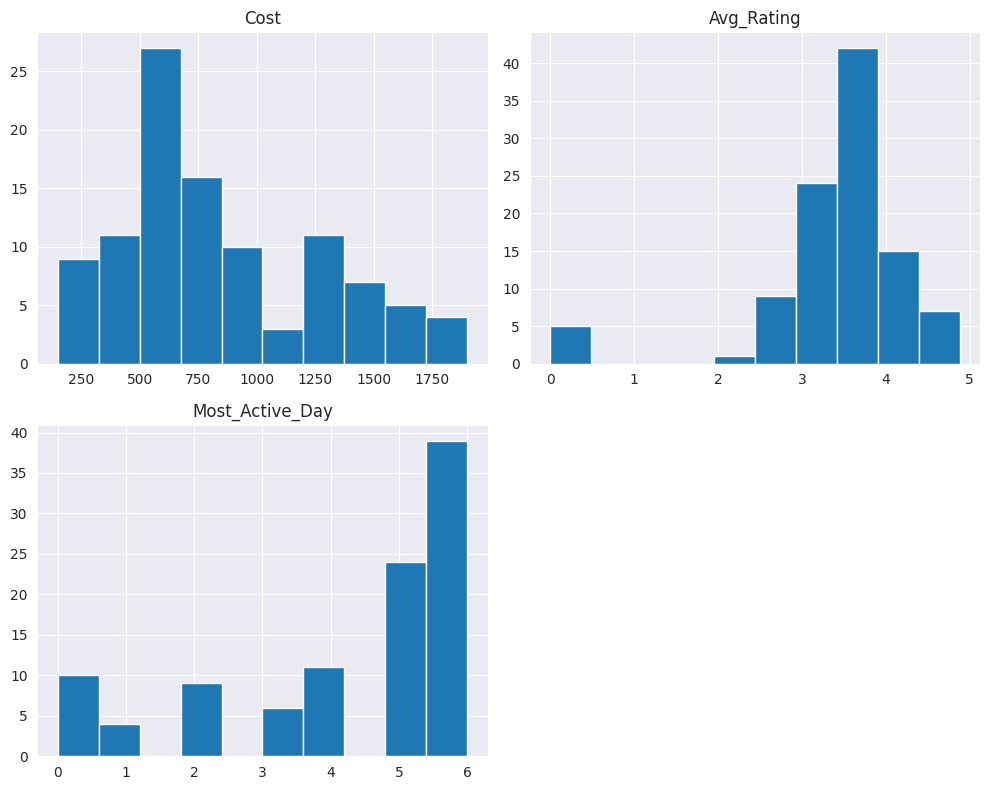

Cost               0.659536
Avg_Rating        -2.338534
Most_Active_Day   -0.991291
dtype: float64


In [ ]:
# Check the distribution of numerical features
restaurants_df_numerical.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Check for skewness
skewness = restaurants_df_numerical.skew()
print(skewness)

In [ ]:
# Transform Your data

I don't feel the need of data transformation.

### 6. Data Scaling

In [ ]:
# Scaling your data

              Cost  Avg_Rating  Most_Active_Day
count   103.000000  103.000000       103.000000
mean    826.699029    3.423706         4.252427
std     448.298282    0.922039         2.008406
min     150.000000    0.000000         0.000000
25%     500.000000    3.195000         3.000000
50%     700.000000    3.590000         5.000000
75%    1200.000000    3.837500         6.000000
max    1900.000000    4.880000         6.000000


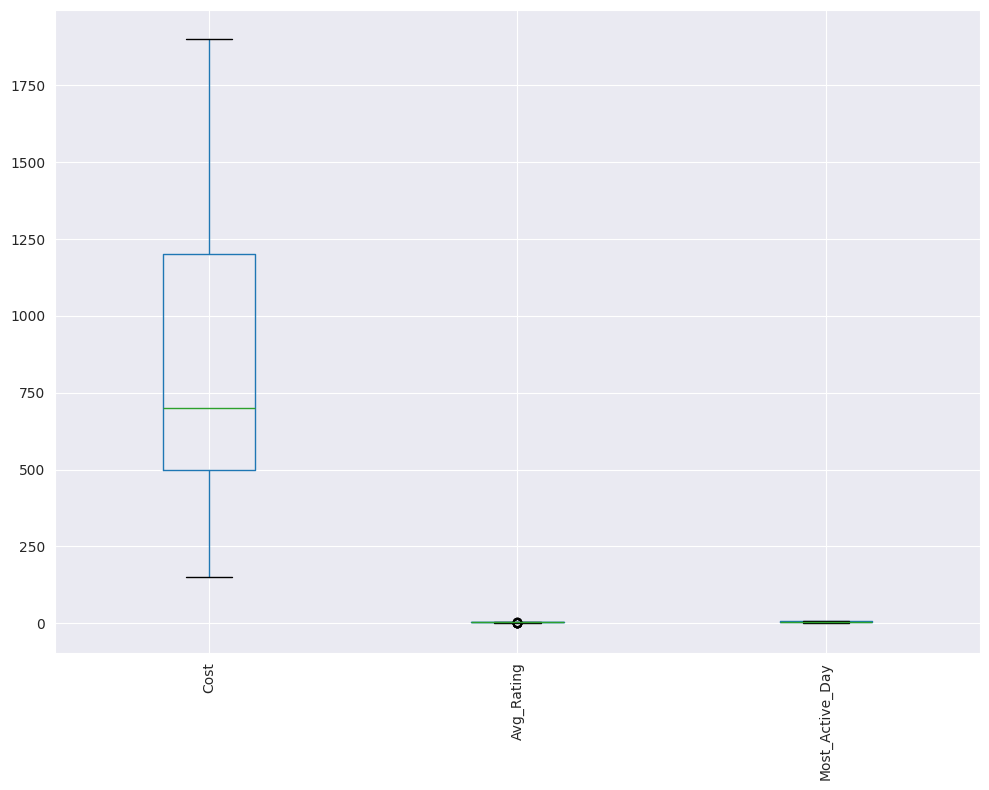

In [ ]:
# Check the range of numerical features
print(restaurants_df_numerical.describe())

# Check for outliers
plt.figure(figsize=(10, 8))
restaurants_df_numerical.boxplot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Yes, there is a need of data scaling as one column is having data between 0-5 and another column is having a data points in 0-2000.

In [ ]:
# Scale the data using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(restaurants_df_numerical)

# Create a new DataFrame with scaled data
scaled_df = pd.DataFrame(scaled_data, columns=restaurants_df_numerical.columns)

# Drop the original numerical columns from 'restaurants_df'
restaurants_df = restaurants_df.drop(columns=restaurants_df_numerical.columns)

# Concatenate the scaled features with the remaining columns in 'restaurants_df'
restaurants_df_scaled = pd.concat([restaurants_df, scaled_df], axis=1)

# Display the updated DataFrame
restaurants_df_scaled


,Name,Collections,Cuisines,Timings,Collections_Normalized,Cuisines_Normalized,Collections_POS_Tagged,Cuisines_POS_Tagged,Collections_Str,Cuisines_Str,Cost,Avg_Rating,Most_Active_Day
0,10 Downing Street,trending week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,"[trend, week]","[north, indian, chinese, continent]","[(trend, NN), (week, NN)]","[(north, JJ), (indian, JJ), (chinese, JJ), (co...",trend week,north indian chinese continent,2.405875,0.410107,0.874384
1,13 Dhaba,veggie friendly,North Indian,"12:30 PM to 10 PM (Tue-Sun), Mon Closed","[veggi, friendli]","[north, indian]","[(veggi, NN), (friendli, NN)]","[(north, JJ), (indian, JJ)]",veggi friendli,north indian,-0.844396,0.061353,0.874384
2,"3B's - Buddies, Bar & Barbecue",barbecue grill live sports screenings,"North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM","[barbecu, grill, live, sport, screen]","[north, indian, mediterranean, european]","[(barbecu, NN), (grill, NN), (live, JJ), (spor...","[(north, JJ), (indian, JJ), (mediterranean, NN...",barbecu grill live sport screen,north indian mediterranean european,0.612622,1.456369,-0.626642
3,AB's - Absolute Barbecues,barbecue grill great buffets corporate favorit...,"European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM","[barbecu, grill, great, buffet, corpor, favori...","[european, mediterranean, north, indian]","[(barbecu, NN), (grill, NN), (great, JJ), (buf...","[(european, JJ), (mediterranean, JJ), (north, ...",barbecu grill great buffet corpor favorit hyde...,european mediterranean north indian,1.509248,1.587151,0.374042
4,Absolute Sizzlers,great buffets,"Continental, American, Chinese",11:30 AM to 1 AM,"[great, buffet]","[continental, american, chines]","[(great, JJ), (buffet, NN)]","[(continental, JJ), (american, JJ), (chines, N...",great buffet,continental american chines,-0.171926,0.213933,-0.126300
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Wich Please,na,Fast Food,8am to 12:30AM (Mon-Sun),[na],"[fast, food]","[(na, NNS)]","[(fast, RB), (food, NN)]",na,fast food,-1.292709,-3.731346,-2.127668
99,Yum Yum Tree - The Arabian Food Court,food hygiene rated restaurants hyderabad,"North Indian, Hyderabadi",12 Noon to 12 Midnight,"[food, hygien, rate, restaur, hyderabad]","[north, indian, hyderabadi]","[(food, NN), (hygien, NN), (rate, NN), (restau...","[(north, JJ), (indian, JJ), (hyderabadi, NN)]",food hygien rate restaur hyderabad,north indian hyderabadi,0.836779,0.148541,0.874384
100,Zega - Sheraton Hyderabad Hotel,na,"Asian, Sushi",12Noon to 2AM (Mon-Sun),[na],"[asian, sushi]","[(na, NNS)]","[(asian, JJ), (sushi, NN)]",na,asian sushi,2.069640,1.118513,-0.626642
101,Zing's Northeast Kitchen,na,"North Eastern, Momos","11:30 AM to 4 PM, 7 PM to 11 PM",[na],"[north, eastern, momo]","[(na, NNS)]","[(north, JJ), (eastern, JJ), (momo, NN)]",na,north eastern momo,-0.620239,0.246628,0.874384


##### Which method have you used to scale you data and why?

I have used StandardScaler to scale the data.

StandardScaler standardizes features by removing the mean and scaling to unit variance.
It's a common choice when you want your features to have a mean of 0 and a standard deviation of 1.

Reasons for using StandardScaler:

- Algorithm Compatibility: Many machine learning algorithms, especially those based on distance
  calculations (e.g., k-nearest neighbors, support vector machines) or gradient descent optimization,
  perform better when features are on a similar scale.

- Normalization: StandardScaler helps normalize the data, making it less sensitive to the
  scale of individual features.

- Outlier Handling: While StandardScaler doesn't directly address outliers, it can reduce their
  impact by scaling the data based on the overall distribution.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

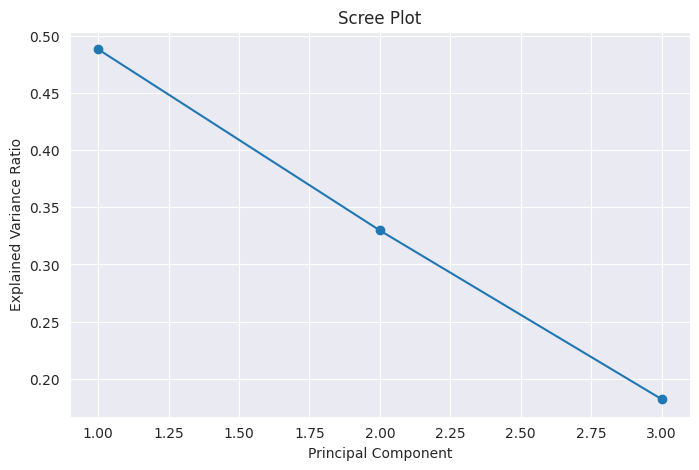

In [ ]:
# Assume X is your feature matrix
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(scaled_df)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

In [ ]:
explained_variance

array([0.48826291, 0.32969015, 0.18204694])

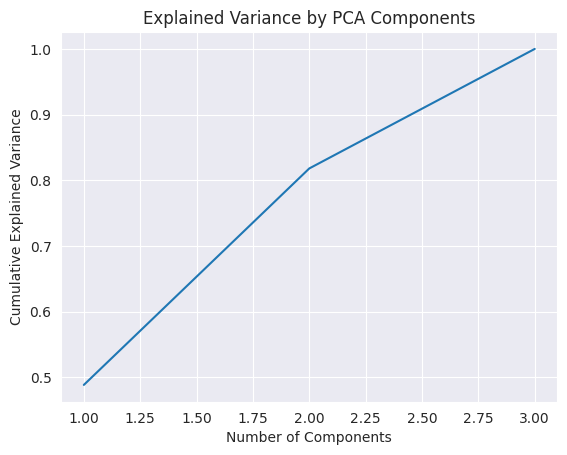

In [ ]:
# Check the explained variance ratio for PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(scaled_df)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
restaurants_df_scaled.head(1)

,Name,Collections,Cuisines,Timings,Collections_Normalized,Cuisines_Normalized,Collections_POS_Tagged,Cuisines_POS_Tagged,Collections_Str,Cuisines_Str,Cost,Avg_Rating,Most_Active_Day
0,10 Downing Street,trending week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,"[trend, week]","[north, indian, chinese, continent]","[(trend, NN), (week, NN)]","[(north, JJ), (indian, JJ), (chinese, JJ), (co...",trend week,north indian chinese continent,2.405875,0.410107,0.874384


In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_model_1 = restaurants_df_scaled.drop(['Name','Collections','Cuisines','Timings','Collections_Normalized','Cuisines_Normalized','Collections_POS_Tagged','Cuisines_POS_Tagged','Avg_Rating'], axis=1)
y_model_1 = restaurants_df_scaled['Avg_Rating']

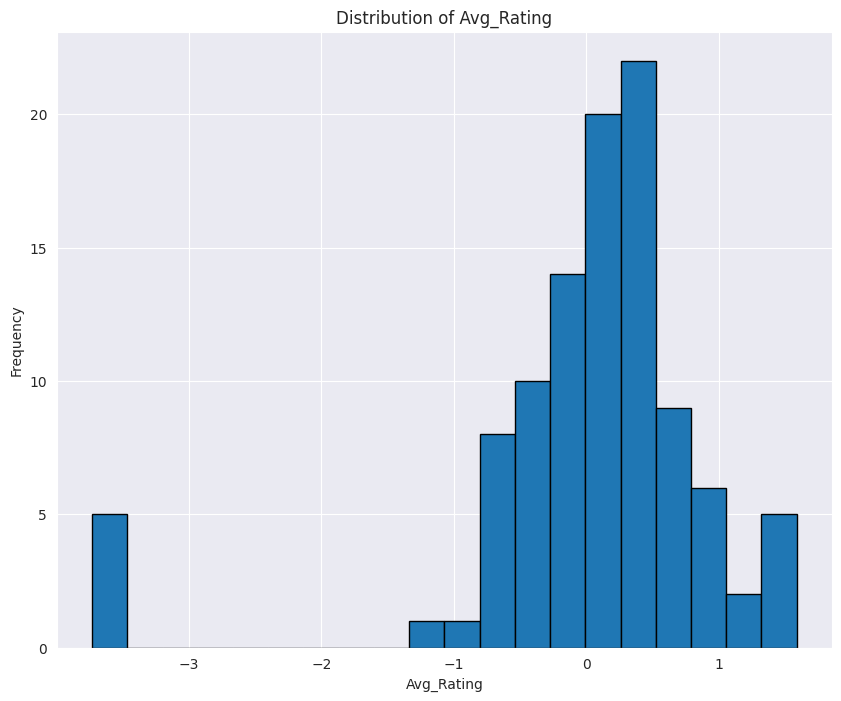

In [ ]:
plt.figure(figsize=(10, 8))
plt.hist(y_model_1, bins=20, edgecolor='k')
plt.xlabel('Avg_Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Avg_Rating')
plt.show()

##### What data splitting ratio have you used and why?

The test_size parameter in train_test_split determines the proportion of the data that will be allocated to the testing set.
In this case, test_size = 0.2 means that 20% of the data will be used for testing, and the remaining 80% will be used for training.

This splitting ratio is a common choice for several reasons:

- Adequate Evaluation: A 20% test set is generally large enough to provide a reasonable estimate of the model's performance on unseen data.
- Sufficient Training Data:  The remaining 80% for training allows the model to learn patterns from a substantial portion of the data.
- Balance: It strikes a balance between having enough data to evaluate the model and enough data to train the model effectively.

However, the optimal test size can vary depending on the dataset size, the complexity of the model, and the specific goals of the analysis.
For example, if you have a very small dataset, you might need to use a smaller test size to ensure you have enough data for training.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1


**Objective:** Predict the Avg_Rating of a restaurant based on features like Collections, Cuisines, Timings, Most_Active_Day, and Cost.

**Model Type:** Regression

**Possible Algorithms:**

* Linear Regression: To model the relationship between the predictors and the average rating.

* Random Forest Regressor: A more robust model that can capture non-linear relationships between features and the target.

* XGBoost Regressor: An advanced gradient boosting technique that often performs well in predictive modeling tasks.

In [ ]:
X_model_1[X_model_1['Collections_Str'] == 'na'].count()

,0
Collections_Str,54
Cuisines_Str,54
Cost,54
Most_Active_Day,54


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# Step 1: Replace "na" with proper NaN
# -------------------------------
X_model_1 = X_model_1.replace("na", np.nan)

# -------------------------------
# Step 2: Features and Target
# -------------------------------

# Identify numeric and categorical columns automatically
numeric_features = X_model_1.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_model_1.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# -------------------------------
# Step 3: Preprocessing
# -------------------------------
# Numeric pipeline → fill NaN with median
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline → fill NaN with "Unknown" and OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# -------------------------------
# Step 4: Full Pipeline with RandomForest
# -------------------------------
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------------
# Step 5: Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_model_1, y_model_1, test_size=0.2, random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -------------------------------
# Step 6: Evaluation
# -------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Performance:")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

Numeric features: ['Cost', 'Most_Active_Day']
Categorical features: ['Collections_Str', 'Cuisines_Str']

Random Forest Performance:
RMSE: 0.939
R² Score: 0.215


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest is an ensemble learning method. Instead of building one decision tree, it builds many decision trees and combines their predictions.

**Working:**

Each tree is trained on a random subset of the training data.

Each split in a tree considers only a random subset of features.

For regression, the final prediction is the average of predictions from all trees.

**Preferred because:**

Handles categorical + numeric features well (with preprocessing).

Robust to missing values (since we impute them).

Captures non-linear patterns between features and target.

Reduces overfitting by averaging many trees.

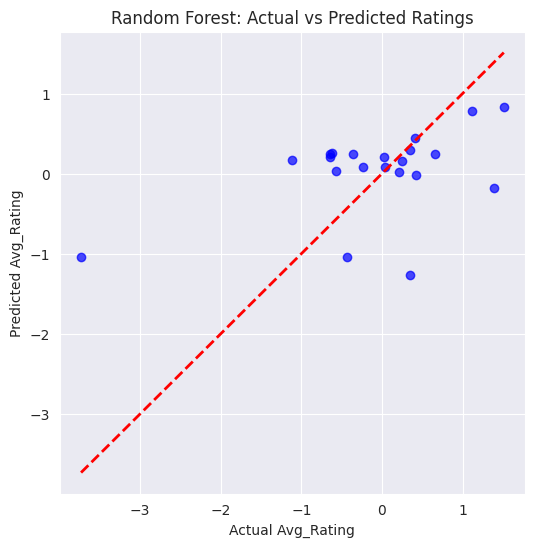

In [ ]:
# Get predictions
y_pred = model.predict(X_test)

# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel("Actual Avg_Rating")
plt.ylabel("Predicted Avg_Rating")
plt.title("Random Forest: Actual vs Predicted Ratings")
plt.show()

Test RMSE: 0.9386391943205411
Test MAE: 0.6851020829075736
Test R²: 0.2148343957244524


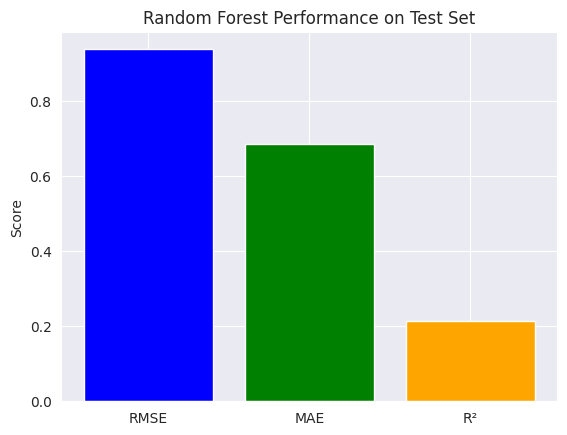

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R²:", r2)

# ---- Plotting Score Chart ----
metrics = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'orange'])
plt.title("Random Forest Performance on Test Set")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ------------------------
# Pipeline with Random Forest
# ------------------------
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(random_state=42))])

# ------------------------
# Define parameter grid for GridSearchCV
# ------------------------
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2']
}

# ------------------------
# Run Grid Search
# ------------------------
grid_search = GridSearchCV(pipeline, param_grid,
                           cv=5, n_jobs=-1,
                           scoring='neg_mean_squared_error',
                           verbose=2)

grid_search.fit(X_train, y_train)

# ------------------------
# Evaluate best model
# ------------------------
print("Best Parameters:", grid_search.best_params_)

y_pred = grid_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'regressor__max_depth': 20, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Test RMSE: 0.9370295233268315


##### Which hyperparameter optimization technique have you used and why?

**Answer:** Grid search CV because my dataset is small.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

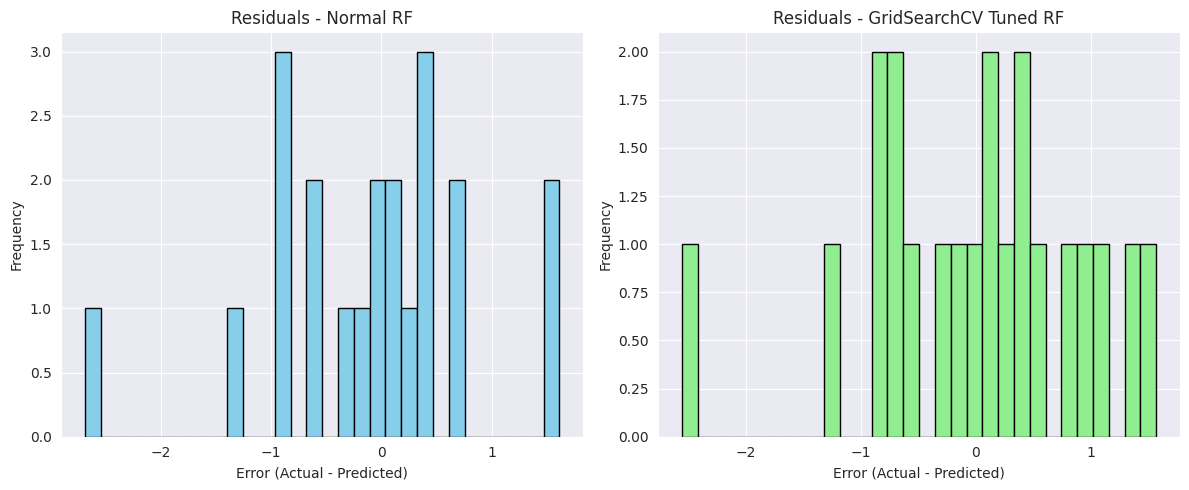

In [ ]:
# -----------------------------
# Residuals for Normal RF Model
# -----------------------------
y_pred_normal = model.predict(X_test)   # from your base RandomForest pipeline
residuals_normal = y_test - y_pred_normal

# -----------------------------
# Residuals for Tuned Model (GridSearchCV)
# -----------------------------
y_pred_tuned = grid_search.predict(X_test)
residuals_tuned = y_test - y_pred_tuned

# -----------------------------
# Plot Residual Distribution
# -----------------------------
plt.figure(figsize=(12,5))

# Normal RF residuals
plt.subplot(1,2,1)
plt.hist(residuals_normal, bins=30, color='skyblue', edgecolor='black')
plt.title("Residuals - Normal RF")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")

# Tuned RF residuals
plt.subplot(1,2,2)
plt.hist(residuals_tuned, bins=30, color='lightgreen', edgecolor='black')
plt.title("Residuals - GridSearchCV Tuned RF")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Answer:** Here we can observe that our normal Random Forest model is giving more accurate result as compared to tuned model.

### ML Model - 2

**Objective:** Segment restaurants into different clusters based on their features like Collections, Cuisines, Cost, and Avg_Rating.

**Model Type:** Clustering

**Possible Algorithms:**

* K-Means Clustering: To segment restaurants into distinct groups based on similarity in features.

* DBSCAN (Density-Based Spatial Clustering of Applications with Noise): For identifying clusters based on density, useful if you expect noise or outliers in your data.

* Hierarchical Clustering: For a tree-based approach to clustering that doesn't require specifying the number of clusters in advance.

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_model_2 = restaurants_df_scaled.drop(['Name','Collections','Cuisines','Timings','Collections_Normalized','Cuisines_Normalized','Collections_POS_Tagged','Cuisines_POS_Tagged'], axis=1)

In [ ]:
X_model_2.head(1)

,Collections_Str,Cuisines_Str,Cost,Avg_Rating,Most_Active_Day
0,trend week,north indian chinese continent,2.405875,0.410107,0.874384


In [ ]:
# ML Model - 2 Implementation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.sparse import hstack

# TF-IDF for text features
tfidf_col = TfidfVectorizer()
collections_matrix = tfidf_col.fit_transform(X_model_2['Collections_Str'])

tfidf_cui = TfidfVectorizer()
cuisines_matrix = tfidf_cui.fit_transform(X_model_2['Cuisines_Str'])

# Scale numerical features
scaler = StandardScaler()
num_features = scaler.fit_transform(X_model_2[['Cost','Avg_Rating']])

# Combine all features
X = hstack([collections_matrix, cuisines_matrix, num_features])

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Predict on the model
X_model_2['Cluster'] = kmeans.predict(X)

# Evaluate initial model
sil_score = silhouette_score(X, X_model_2['Cluster'])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.20480449813775908


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

ML Model Used: **K-Means Clustering**

K-Means is an unsupervised learning algorithm that groups data points into K distinct clusters based on similarity.

It works by:

- Selecting K centroids

- Assigning each data point to the nearest centroid

- Minimizing within-cluster variance (Inertia)

Why K-Means was chosen?

- The objective is segmentation (no target variable).

- Dataset contains numerical + TF-IDF transformed text features.

- K-Means performs well with high-dimensional data.

- It is computationally efficient and scalable.

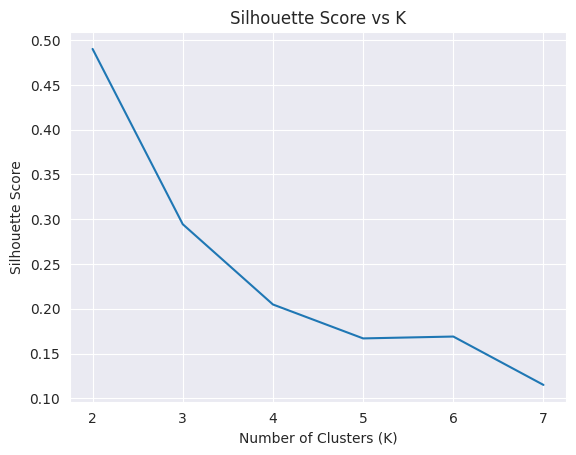

In [ ]:
# Visualizing evaluation Metric Score chart
k_values = range(2,8)
scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(k_values, scores)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
best_score = -1
best_k = None

for k in range(2,10):
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=500,
        random_state=42
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)

Best K: 3
Best Silhouette Score: 0.28882359787857803


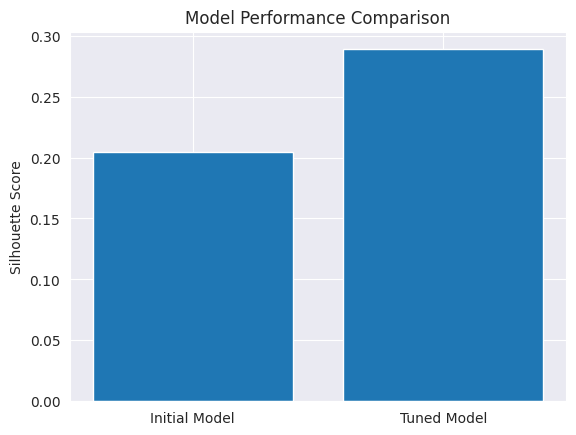

In [ ]:
scores = [sil_score, best_score]
models = ['Initial Model', 'Tuned Model']

plt.bar(models, scores)
plt.ylabel("Silhouette Score")
plt.title("Model Performance Comparison")
plt.show()

##### **Which hyperparameter optimization technique have you used and why?**

I have used **Manual Grid Search using Silhouette Score**.

Because:

- Clustering has no true labels.

- Traditional cross-validation (like K-Fold) cannot be applied.

- Silhouette Score acts as an internal validation metric.

- Multiple values of n_clusters, n_init, and max_iter were tested.

This approach ensures:

- Best cluster separation

- Improved internal validation score

- More stable centroid initialization

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes.

Silhouette Score improved from:
0.2048 → 0.2888

This indicates:

- Better intra-cluster similarity

- Better inter-cluster separation

- More meaningful segmentation

The improvement confirms that hyperparameter tuning positively impacted the clustering structure.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Evaluation metric: **Silhouette Score**

It indicates:

- Measures how distinct and well-formed clusters are.

- Higher score = clearer segmentation.

Business Impact:

- If Silhouette Score increases:

- Restaurant segments become more reliable.

- Marketing campaigns can be cluster-specific.

- Pricing strategies can be optimized per segment.

- Reduced overlap between customer targeting groups.

- Better recommendation system accuracy.

Low score means:

- Segments overlap heavily.

- Business targeting may be less precise.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

Now that the data has been preprocessed and split, we can proceed with implementing the machine learning models as outlined in the following sections: Regression, Clustering, and Classification. Each section will address a specific objective and utilize appropriate algorithms as you have described.